# Exp8.0 — Local Backbone Temporal-Scale Sweep

This notebook is aggregation-only. It reads finalized CSV/JSON artifacts produced by the Exp8.0 finalizer and does not retrain models or refit probes.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

repo = Path.cwd()
if repo.name == 'notebooks':
    repo = repo.parent
base = repo / 'notebooks' / 'artifacts' / 'experiment_8_0_local_backbone_tau_sweep' / 'local_backbone_tau_sweep_v1'
manifest = json.loads((base / 'manifest.json').read_text())
runs = pd.read_csv(base / 'method_runs.csv')
summary = pd.read_csv(base / 'method_summary.csv')
contrast_runs = pd.read_csv(base / 'contrast_runs.csv')
contrast_summary = pd.read_csv(base / 'contrast_summary.csv')
activity = pd.read_csv(base / 'activity_summary.csv')
rasters = pd.read_csv(base / 'raster_index.csv')
manifest

{'architectures': {'123x123': [[1, 2, 3], [1, 2, 3]],
  '123x234': [[1, 2, 3], [2, 3, 4]],
  '123x345': [[1, 2, 3], [3, 4, 5]],
  '234x234': [[2, 3, 4], [2, 3, 4]],
  '234x345': [[2, 3, 4], [3, 4, 5]]},
 'counts': {'architectures': 5, 'parallel_runs': 15, 'seeds': 3},
 'experiment_id': 'experiment_8_0_local_backbone_tau_sweep',
 'output_lif': {'alpha': 0.0, 'beta': 0.5, 'cap': 1, 'threshold': 0.5},
 'protocol_version': 'local_backbone_tau_sweep_v1',
 'representative_raster_sample': {'label': 'D',
  'paths': {'l1': 'notebooks/artifacts/experiment_8_0_local_backbone_tau_sweep/local_backbone_tau_sweep_v1/rasters/234x234__a2_wcce__task_only__seed11__L1.png',
   'l2': 'notebooks/artifacts/experiment_8_0_local_backbone_tau_sweep/local_backbone_tau_sweep_v1/rasters/234x234__a2_wcce__task_only__seed11__L2.png',
   'output': 'notebooks/artifacts/experiment_8_0_local_backbone_tau_sweep/local_backbone_tau_sweep_v1/rasters/234x234__a2_wcce__task_only__seed11__output.png'},
  'sample_index': 40,
  

## 1. Main method-level comparison

In [2]:
cols = [
    'architecture',
    'linear_test_ba_mean', 'linear_test_ba_std',
    'lif_test_ba_mean', 'lif_test_ba_std',
    'lif_penalty_mean', 'lif_penalty_std',
    'l1_whole_ba_mean', 'l1_fixed250_ba_mean',
    'l2_whole_ba_mean', 'l2_fixed250_ba_mean',
]
display(summary[cols].copy())

,architecture,linear_test_ba_mean,linear_test_ba_std,lif_test_ba_mean,lif_test_ba_std,lif_penalty_mean,lif_penalty_std,l1_whole_ba_mean,l1_fixed250_ba_mean,l2_whole_ba_mean,l2_fixed250_ba_mean
0,234x234,0.562518,0.030017,0.523005,0.034556,0.039512,0.028316,0.586489,0.542112,0.569344,0.586877
1,123x234,0.553999,0.033945,0.515193,0.031014,0.038806,0.035499,0.537826,0.518063,0.565769,0.593982
2,123x123,0.557703,0.029485,0.485446,0.024577,0.072257,0.039576,0.551333,0.527860,0.564303,0.589761
3,123x345,0.525186,0.035343,0.480107,0.012615,0.045079,0.026251,0.509193,0.513204,0.515613,0.552025
4,234x345,0.525588,0.022292,0.474794,0.042180,0.050794,0.019980,0.525519,0.536676,0.557948,0.545653


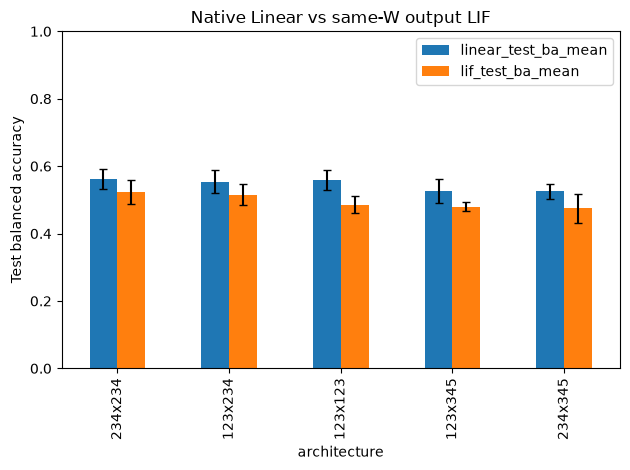

In [3]:
plot_df = summary.set_index('architecture')
ax = plot_df[['linear_test_ba_mean', 'lif_test_ba_mean']].plot(kind='bar', yerr=plot_df[['linear_test_ba_std', 'lif_test_ba_std']].to_numpy().T, capsize=3)
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Native Linear vs same-W output LIF')
ax.set_ylim(0, 1)
plt.tight_layout()

## 2. Representation probes

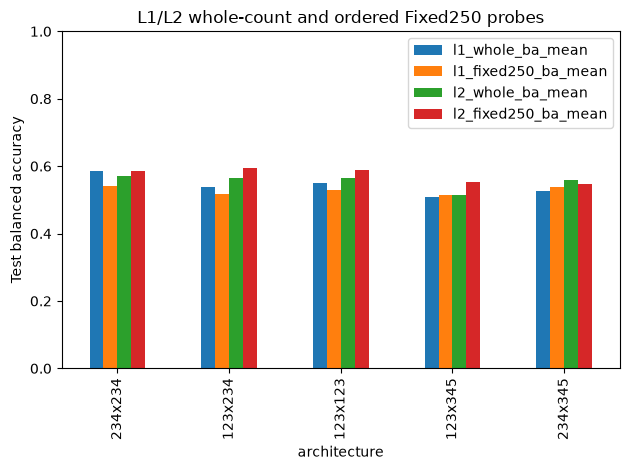

In [4]:
probe_cols = ['l1_whole_ba_mean', 'l1_fixed250_ba_mean', 'l2_whole_ba_mean', 'l2_fixed250_ba_mean']
ax = plot_df[probe_cols].plot(kind='bar')
ax.set_ylabel('Test balanced accuracy')
ax.set_title('L1/L2 whole-count and ordered Fixed250 probes')
ax.set_ylim(0, 1)
plt.tight_layout()

In [5]:
derived = summary[[
    'architecture',
    'l1_temporal_gain_mean', 'l2_temporal_gain_mean',
    'l2_minus_l1_whole_mean', 'l2_minus_l1_fixed250_mean',
]].copy()
display(derived)

,architecture,l1_temporal_gain_mean,l2_temporal_gain_mean,l2_minus_l1_whole_mean,l2_minus_l1_fixed250_mean
0,234x234,-0.044377,0.017533,-0.017146,0.044764
1,123x234,-0.019763,0.028213,0.027943,0.075919
2,123x123,-0.023473,0.025457,0.012970,0.061900
3,123x345,0.004011,0.036412,0.006420,0.038821
4,234x345,0.011157,-0.012295,0.032429,0.008977


## 3. Paired controlled contrasts

In [6]:
display(contrast_summary)

,contrast,architecture_a,architecture_b,delta_linear_test_ba_mean,delta_linear_test_ba_std,delta_lif_test_ba_mean,delta_lif_test_ba_std,delta_l1_whole_ba_mean,delta_l1_whole_ba_std,delta_l1_fixed250_ba_mean,delta_l1_fixed250_ba_std,delta_l2_whole_ba_mean,delta_l2_whole_ba_std,delta_l2_fixed250_ba_mean,delta_l2_fixed250_ba_std
0,fast_L1,123x234,234x234,-0.008519,0.005636,-0.007813,0.005505,-0.048664,0.032335,-0.024049,0.041191,-0.003575,0.059501,0.007105,0.033681
1,L2_short_to_mid,123x234,123x123,-0.003704,0.055510,0.029747,0.035447,-0.013508,0.032479,-0.009797,0.007590,0.001466,0.039805,0.004221,0.052738
2,L2_mid_to_long,123x345,123x234,-0.028813,0.036604,-0.035086,0.043364,-0.028633,0.007786,-0.004859,0.054774,-0.050156,0.080795,-0.041957,0.077745
3,fast_L1_with_long_L2,123x345,234x345,-0.000402,0.049993,0.005313,0.053582,-0.016326,0.012153,-0.023472,0.042811,-0.042335,0.077367,0.006372,0.063258


## 4. Firing/activity diagnostics

In [7]:
display(activity)

,architecture,layer,shift,mean_spikes_per_neuron_s_mean,mean_spikes_per_neuron_s_std,dead_neuron_fraction_mean,dead_neuron_fraction_std
0,234x234,l1,2,0.499699,0.025443,0.108527,0.071048
1,234x234,l1,3,1.775846,0.384074,0.077519,0.013427
2,234x234,l1,4,8.477979,0.421980,0.111111,0.049563
3,234x234,l2,2,22.305526,0.384311,0.000000,0.000000
4,234x234,l2,3,23.159893,1.356125,0.000000,0.000000
5,234x234,l2,4,24.469269,0.445326,0.000000,0.000000
6,234x234,output,0,14.352551,0.484971,0.000000,0.000000
7,123x234,l1,1,0.050262,0.016138,0.341085,0.088045
8,123x234,l1,2,0.587072,0.157118,0.108527,0.058526
9,123x234,l1,3,4.849338,0.216137,0.087302,0.049563


## 5. Per-run raster appendix

Every trained architecture/seed run contributes L1, L2, and same-W output-LIF rasters for the same deterministic representative test sample.

### 123x123 — seed 11

**L1**

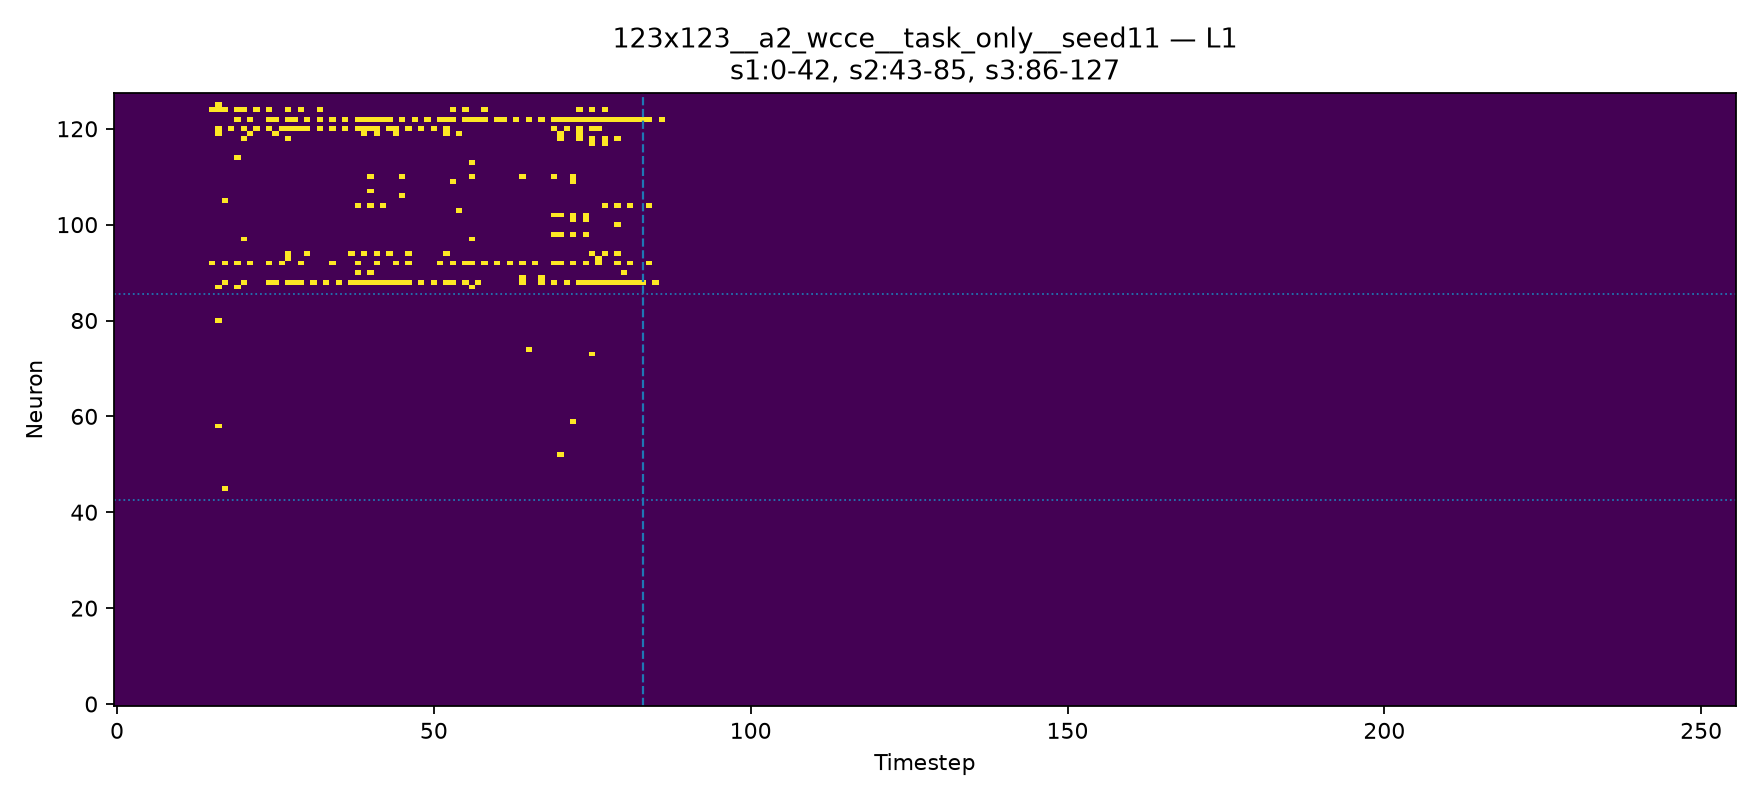

**L2**

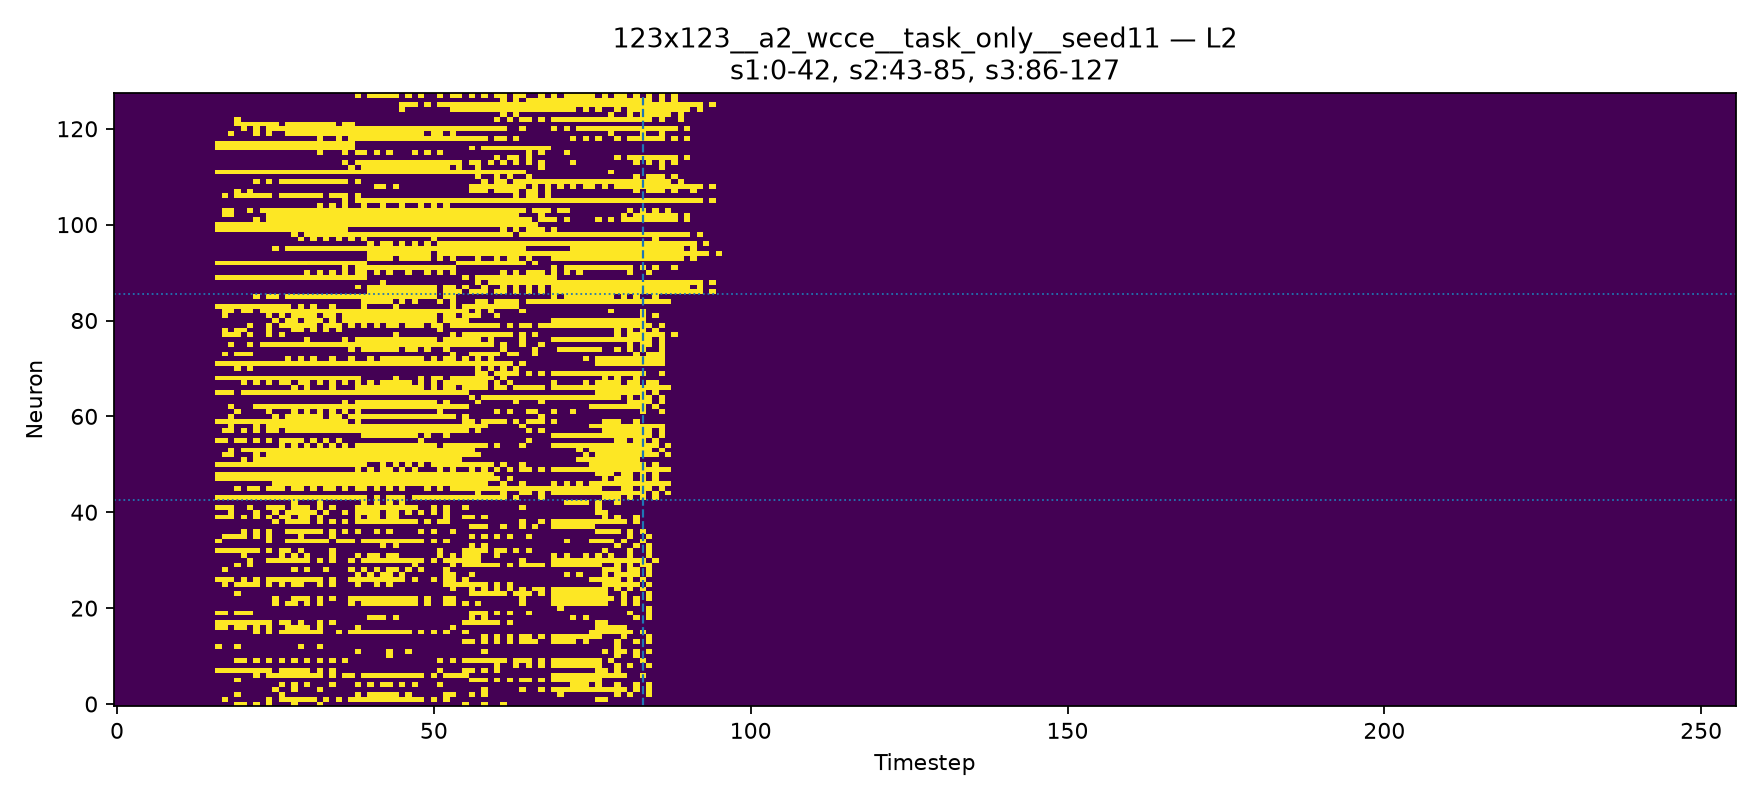

**OUTPUT**

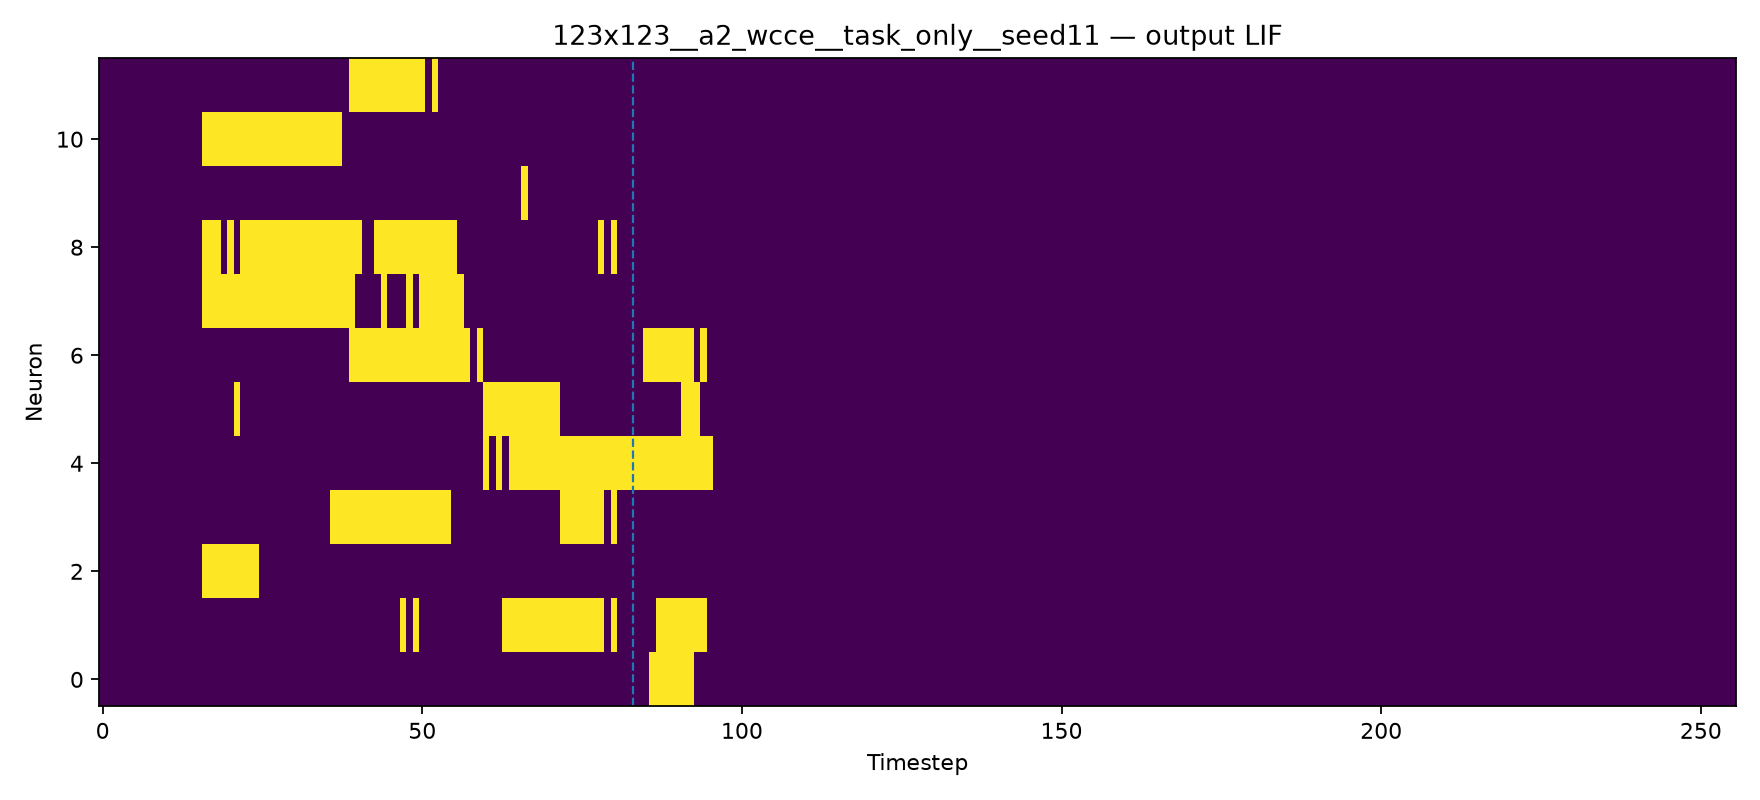

### 123x123 — seed 23

**L1**

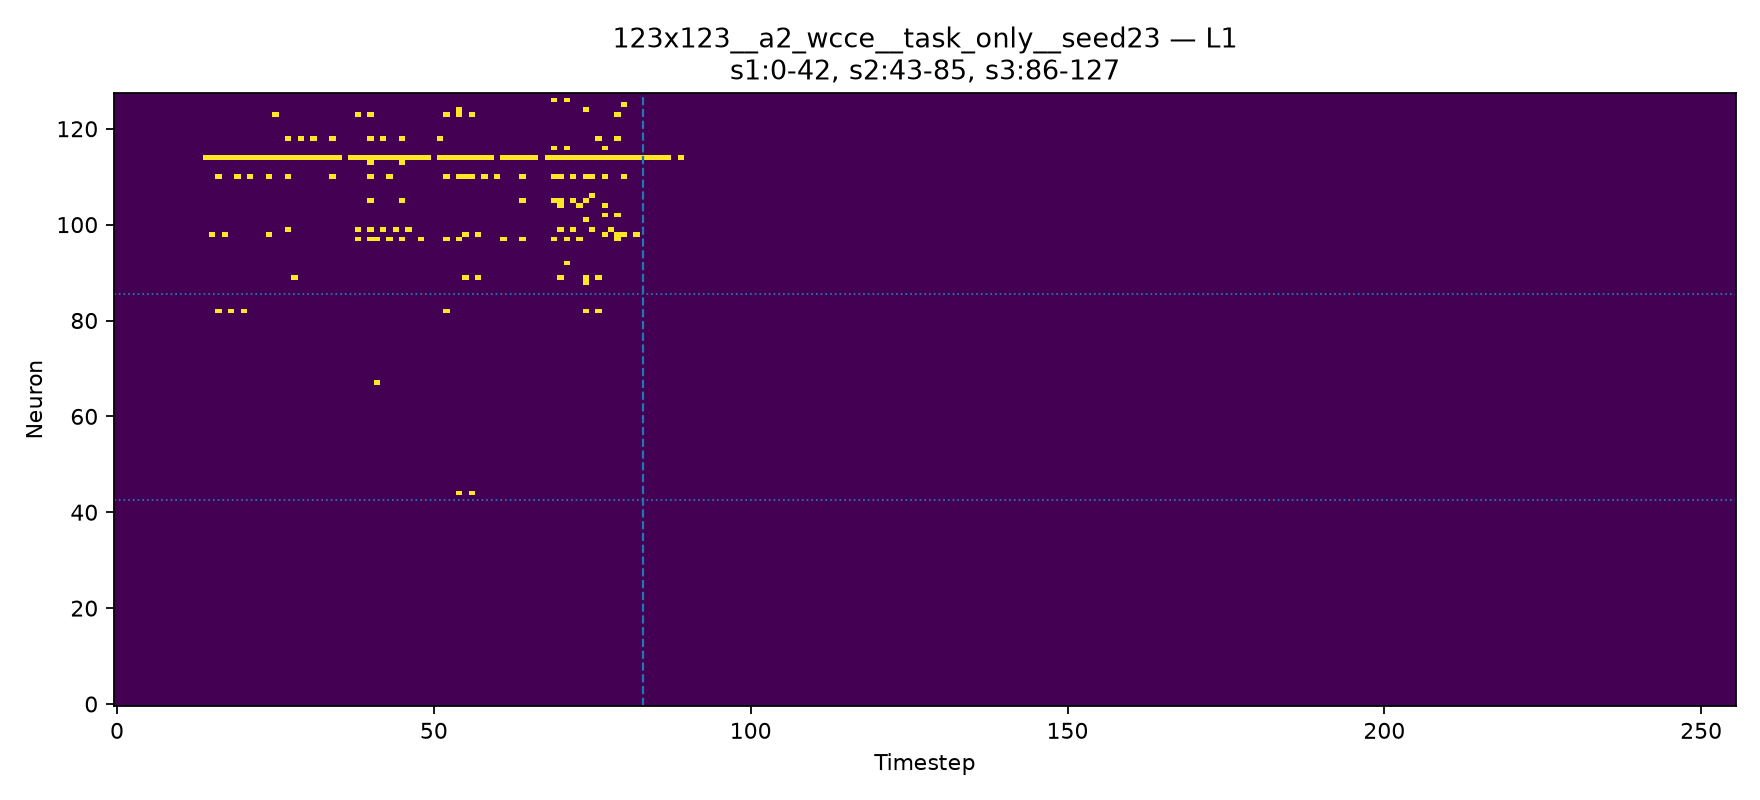

**L2**

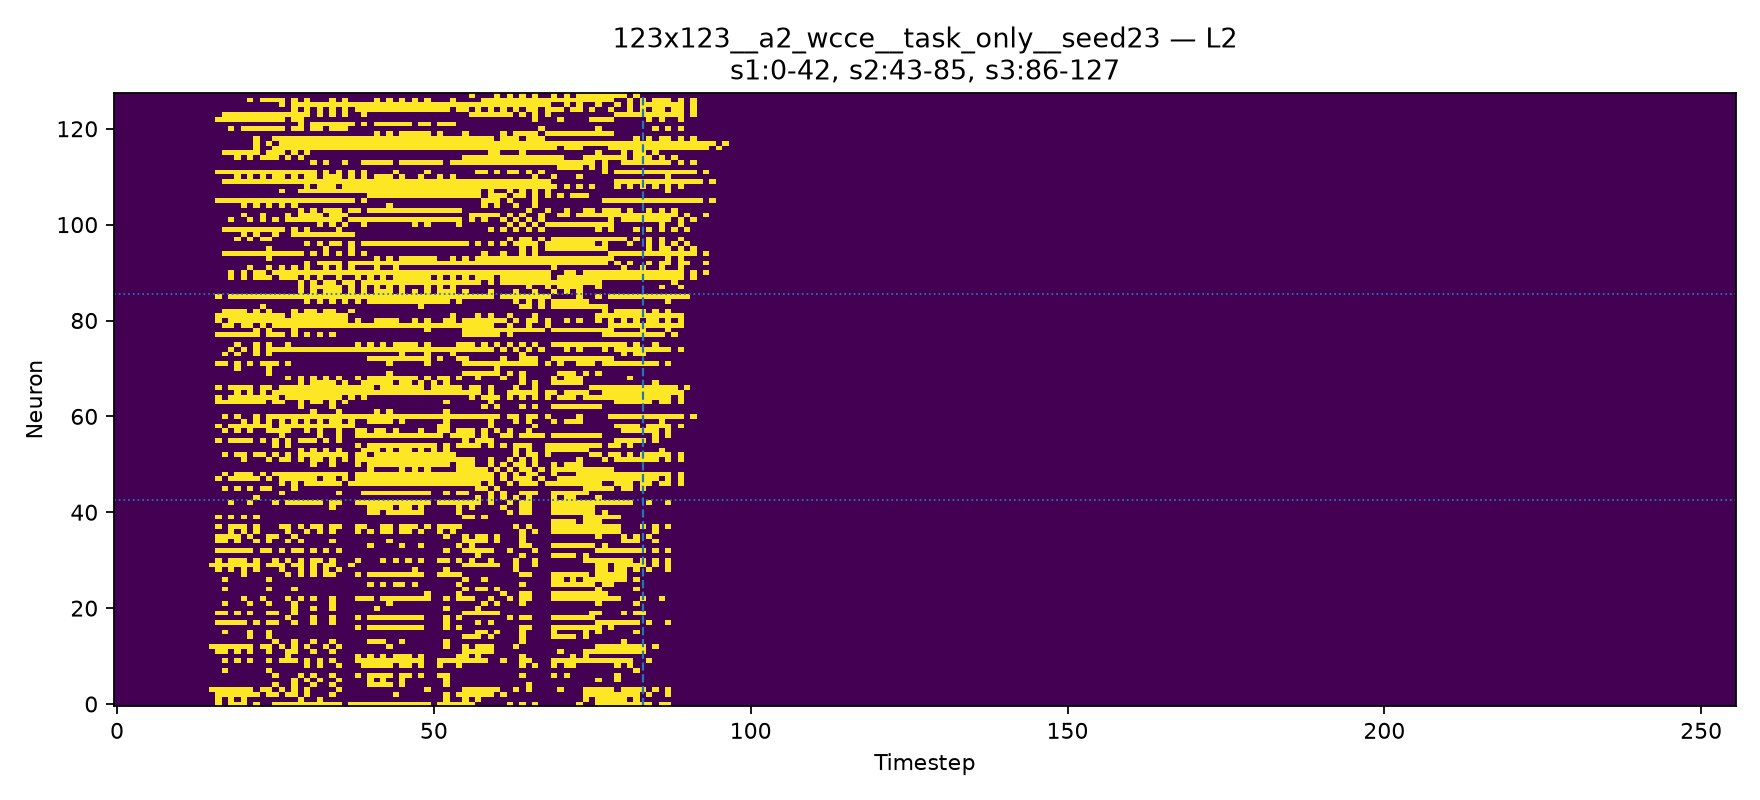

**OUTPUT**

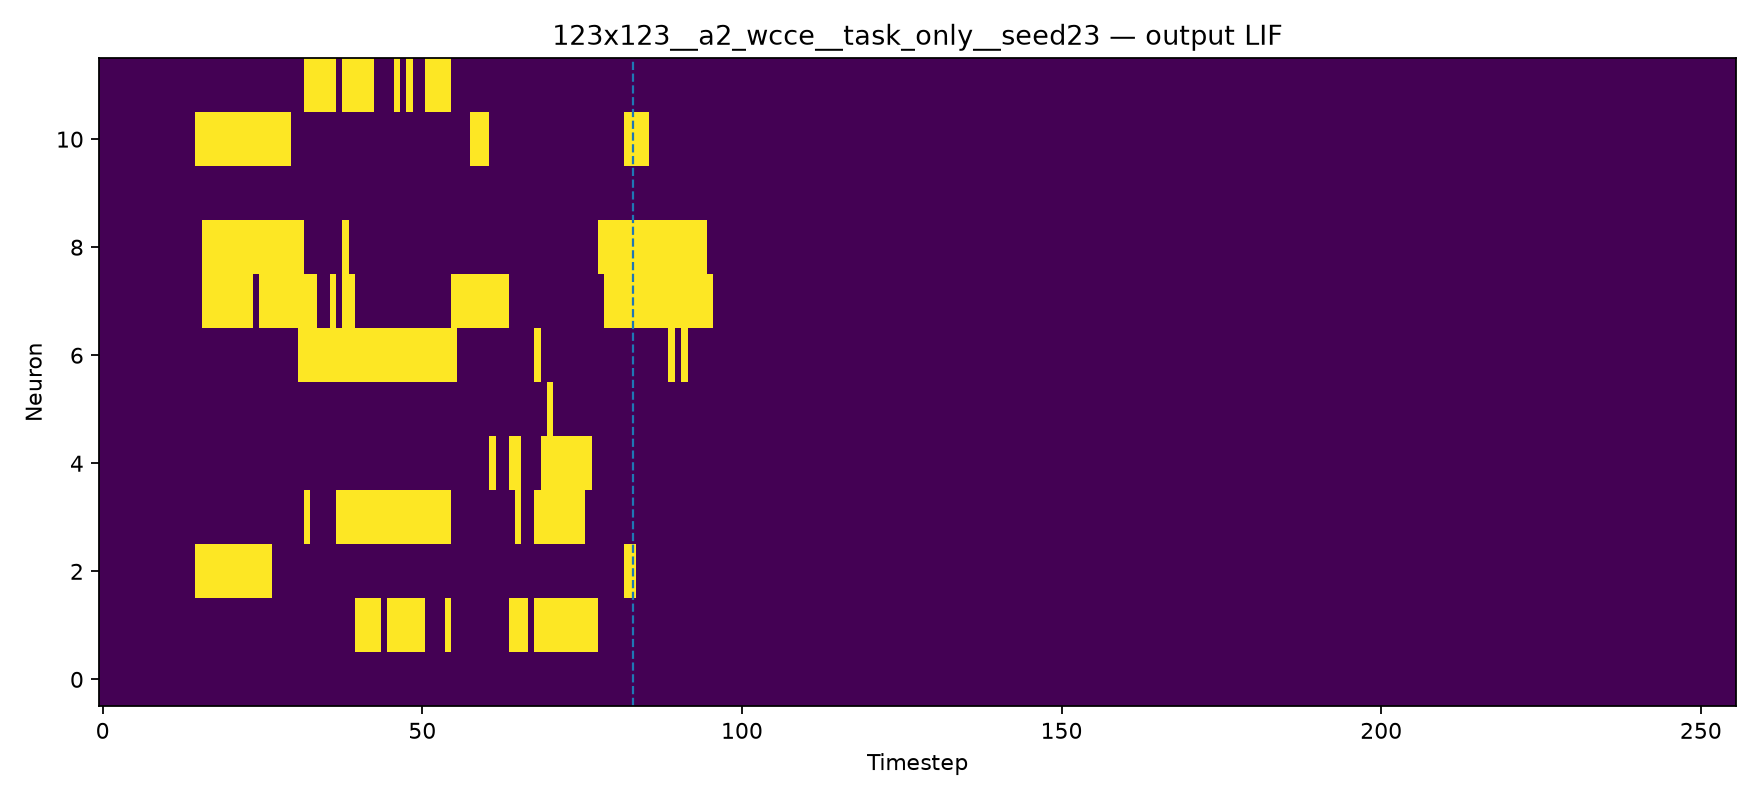

### 123x123 — seed 37

**L1**

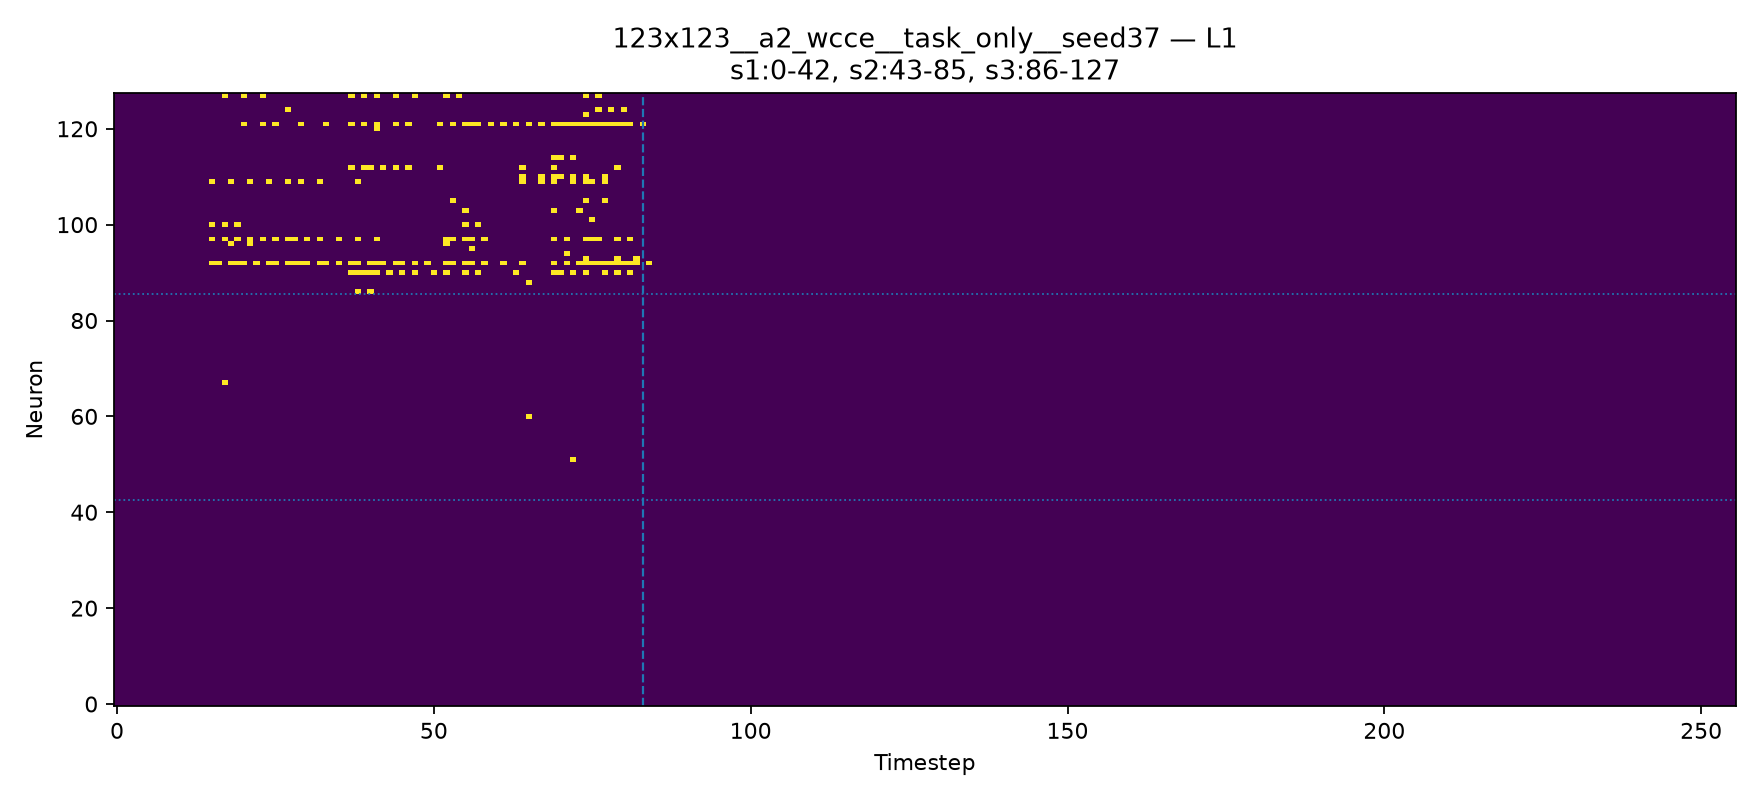

**L2**

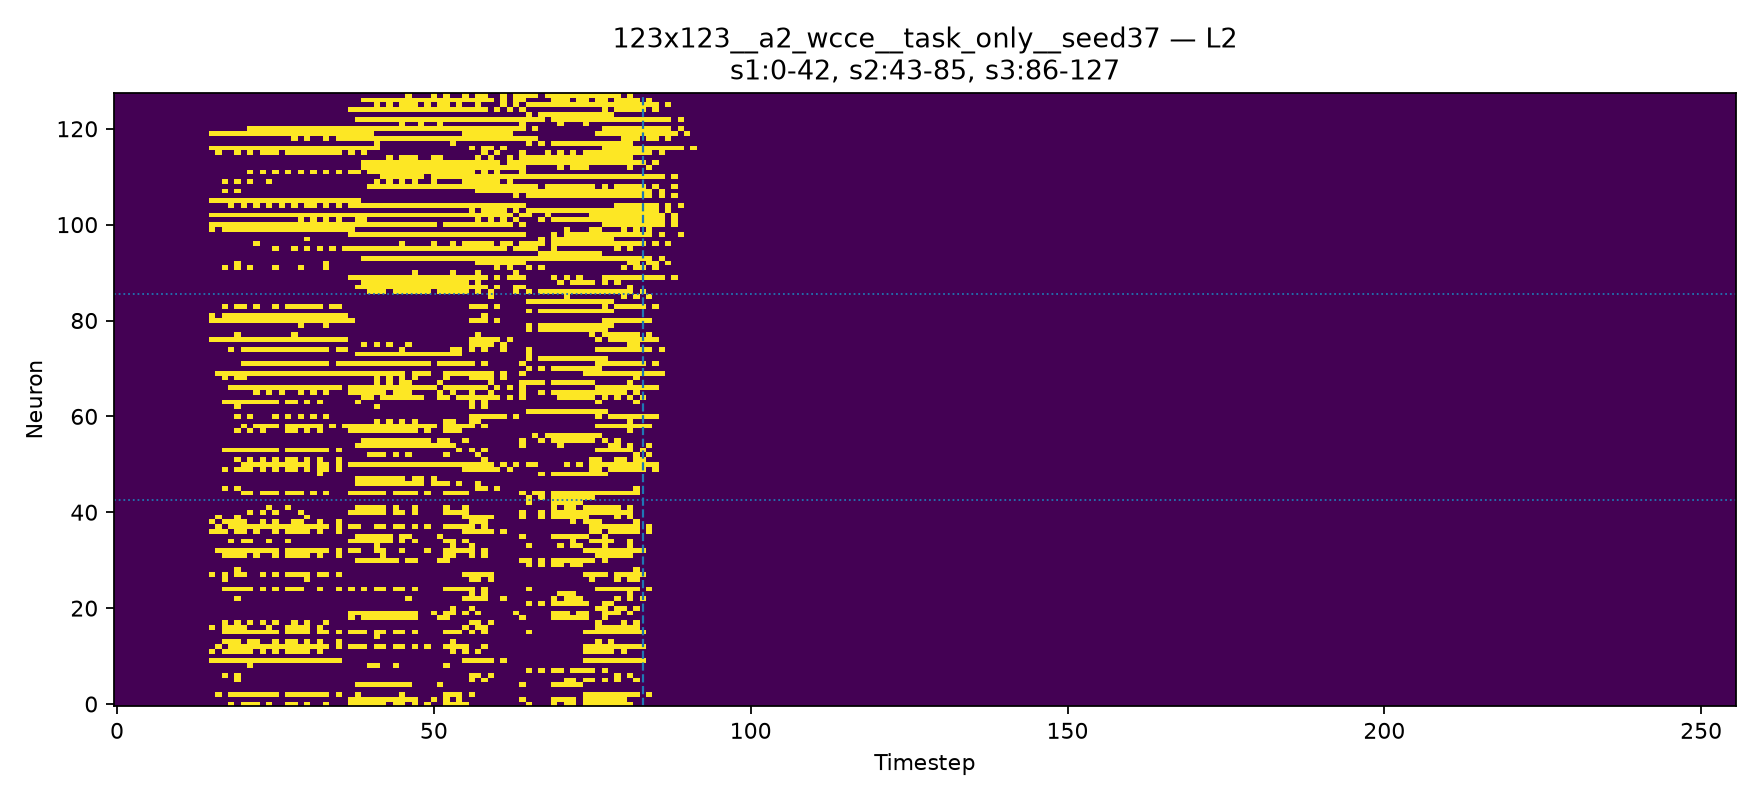

**OUTPUT**

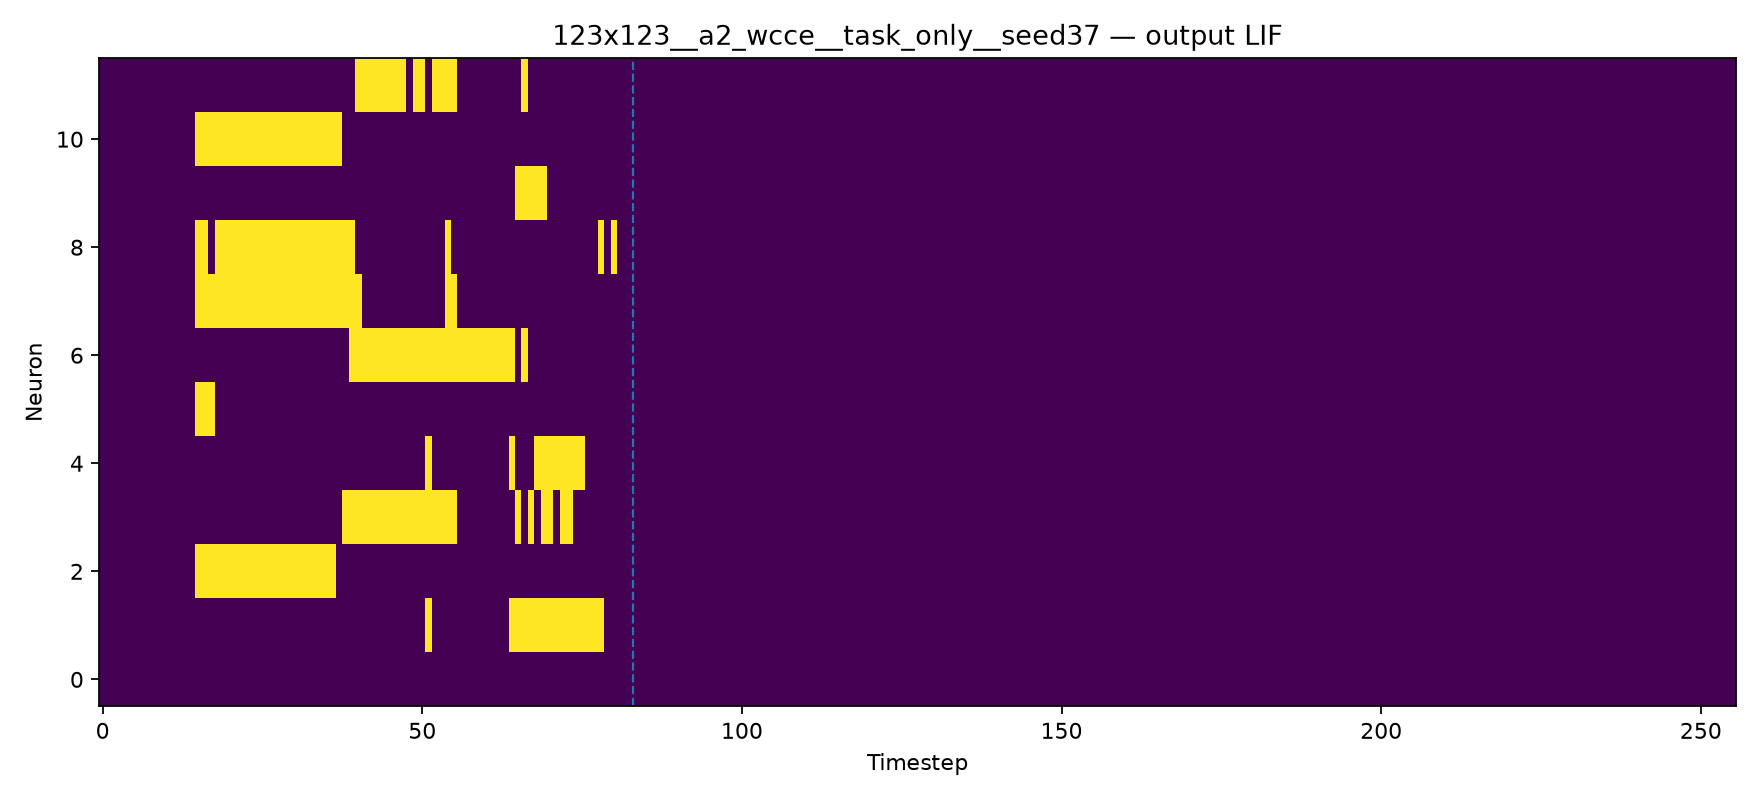

### 123x234 — seed 11

**L1**

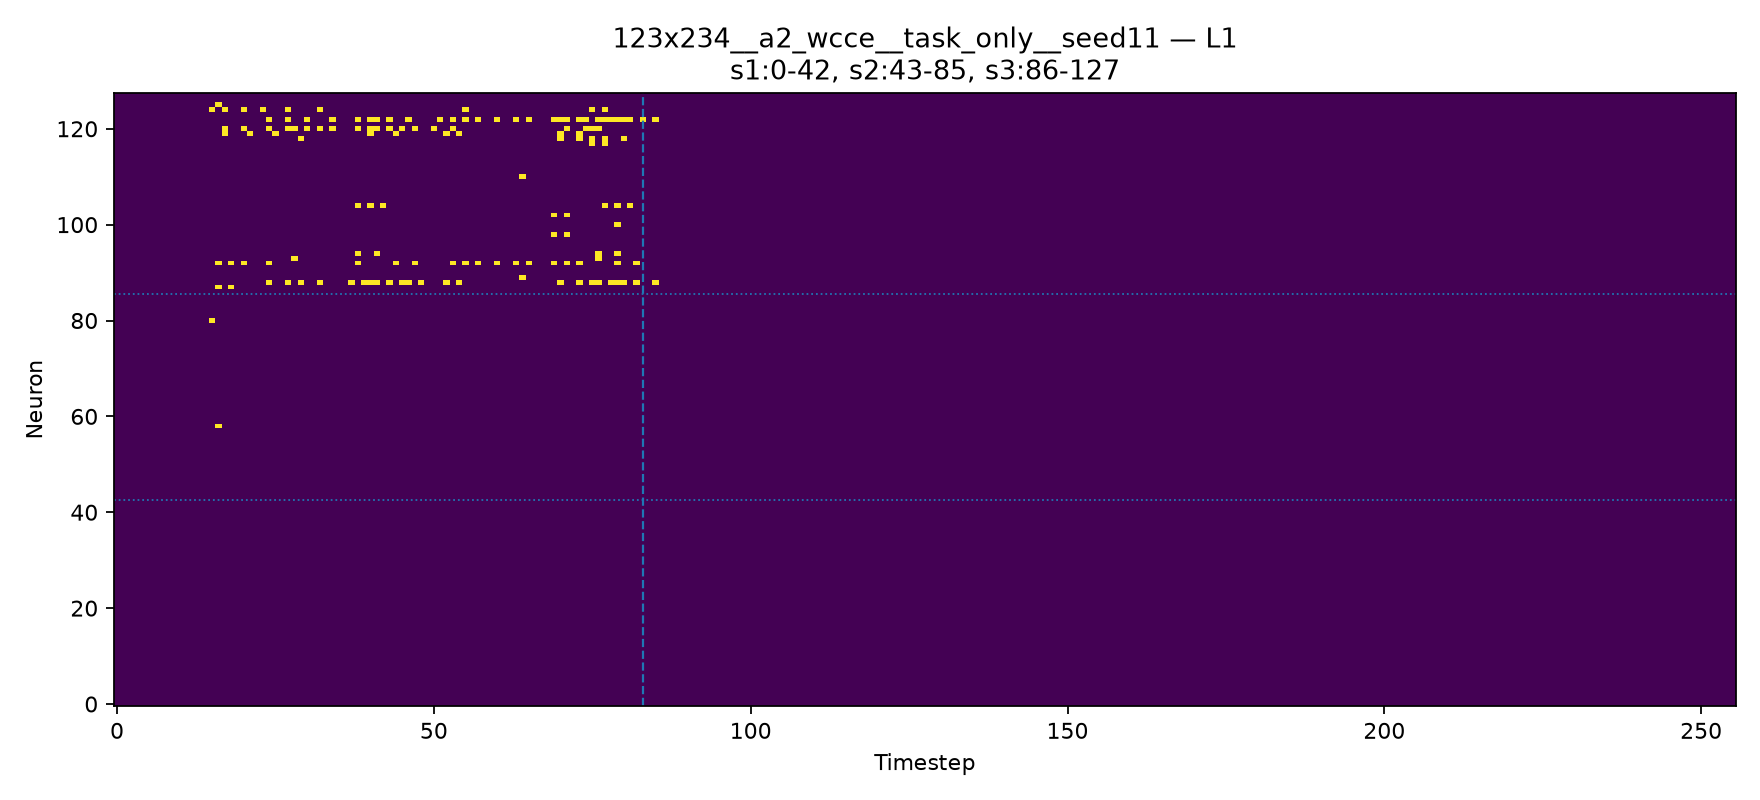

**L2**

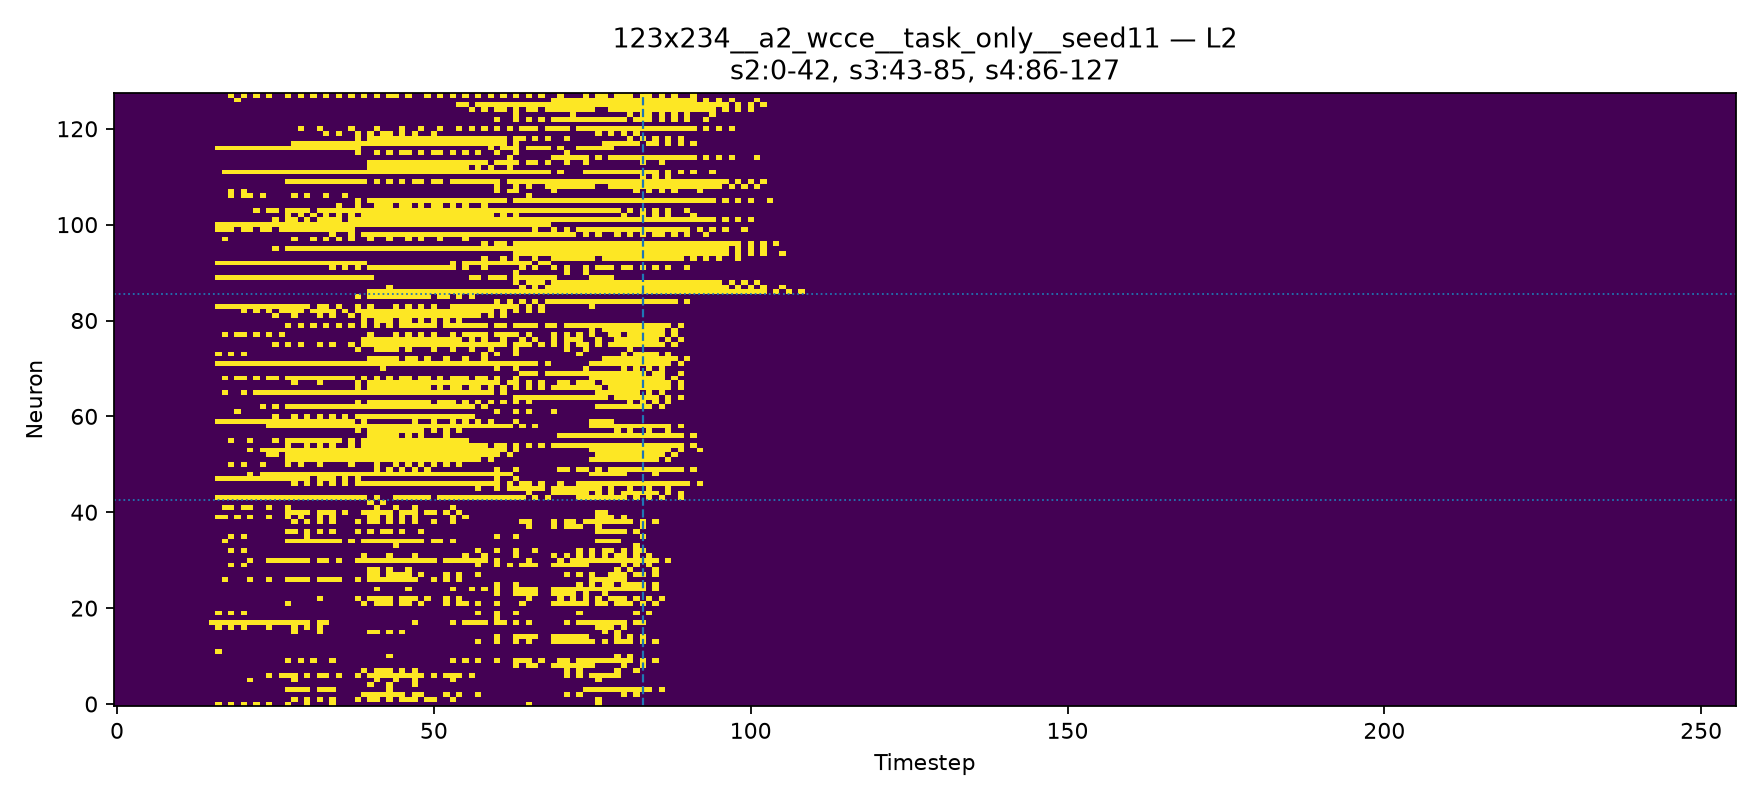

**OUTPUT**

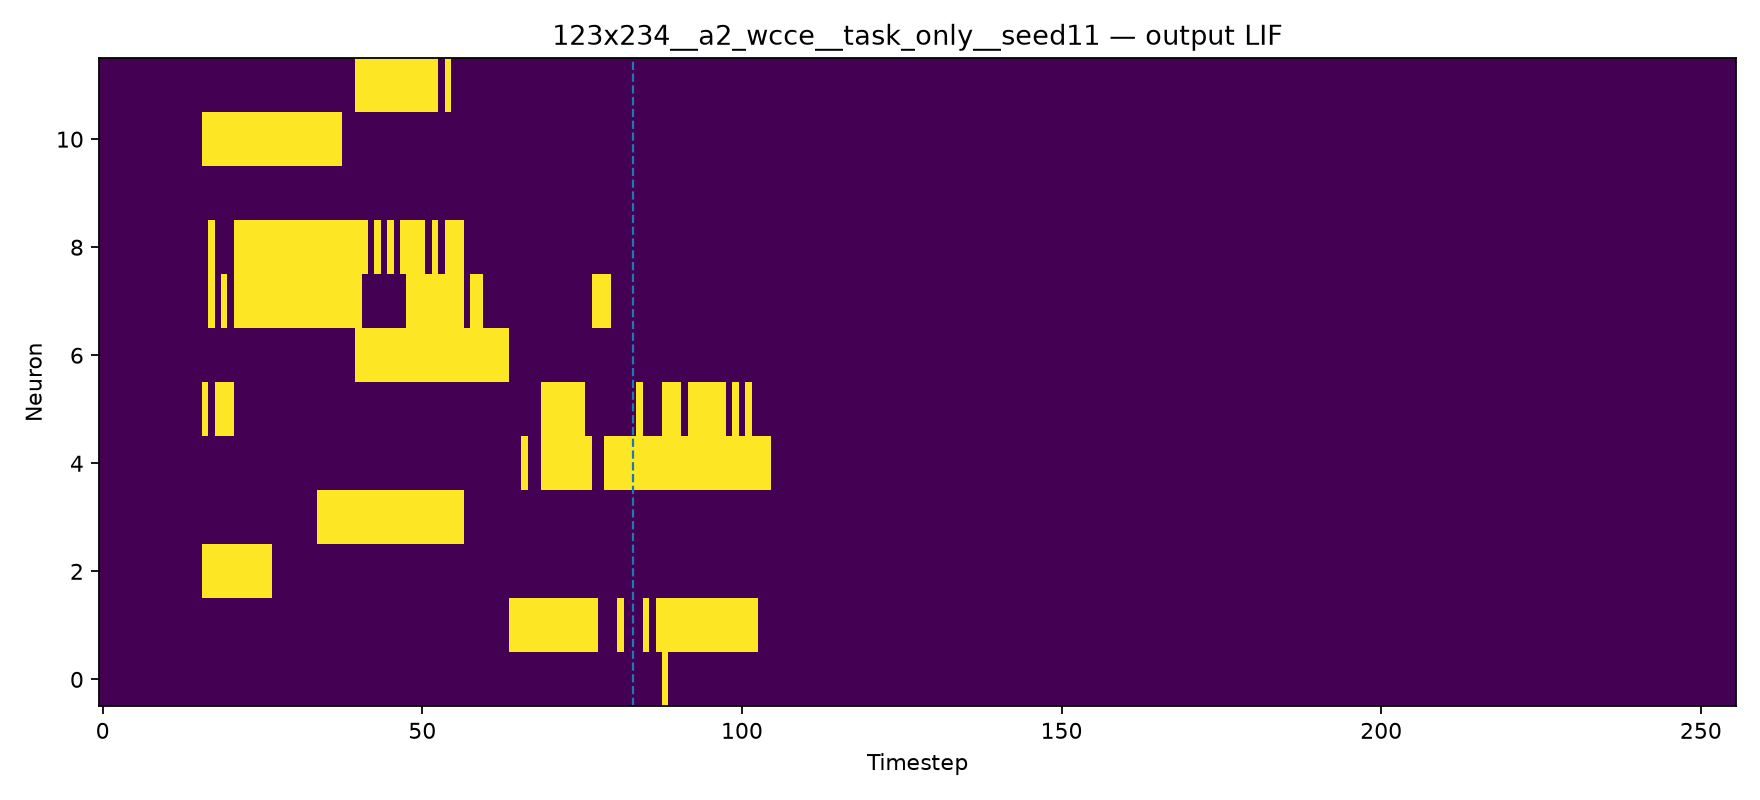

### 123x234 — seed 23

**L1**

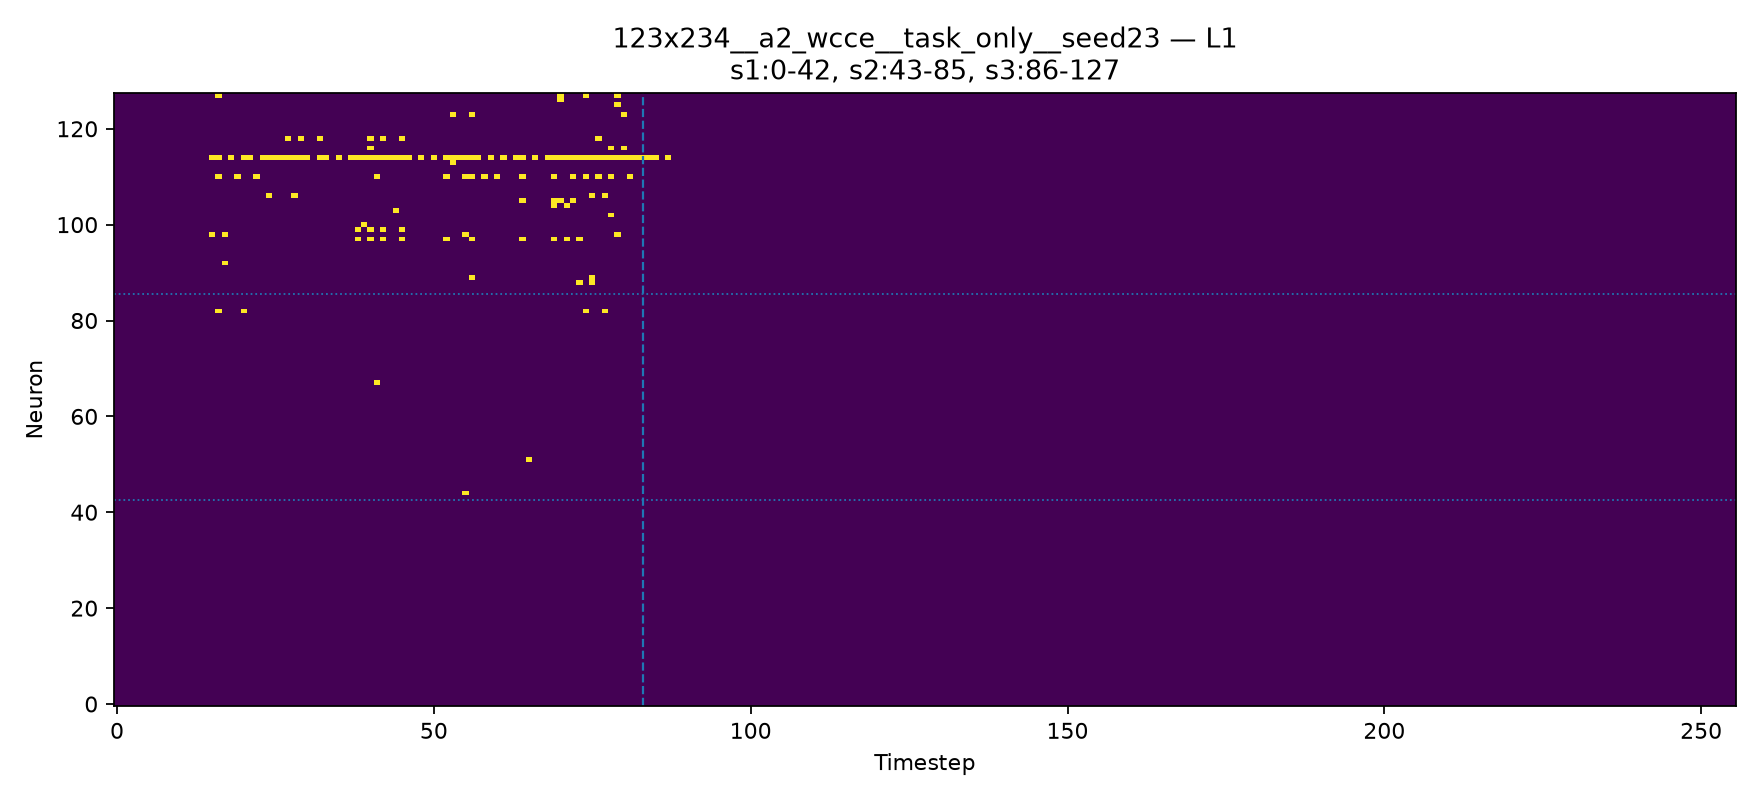

**L2**

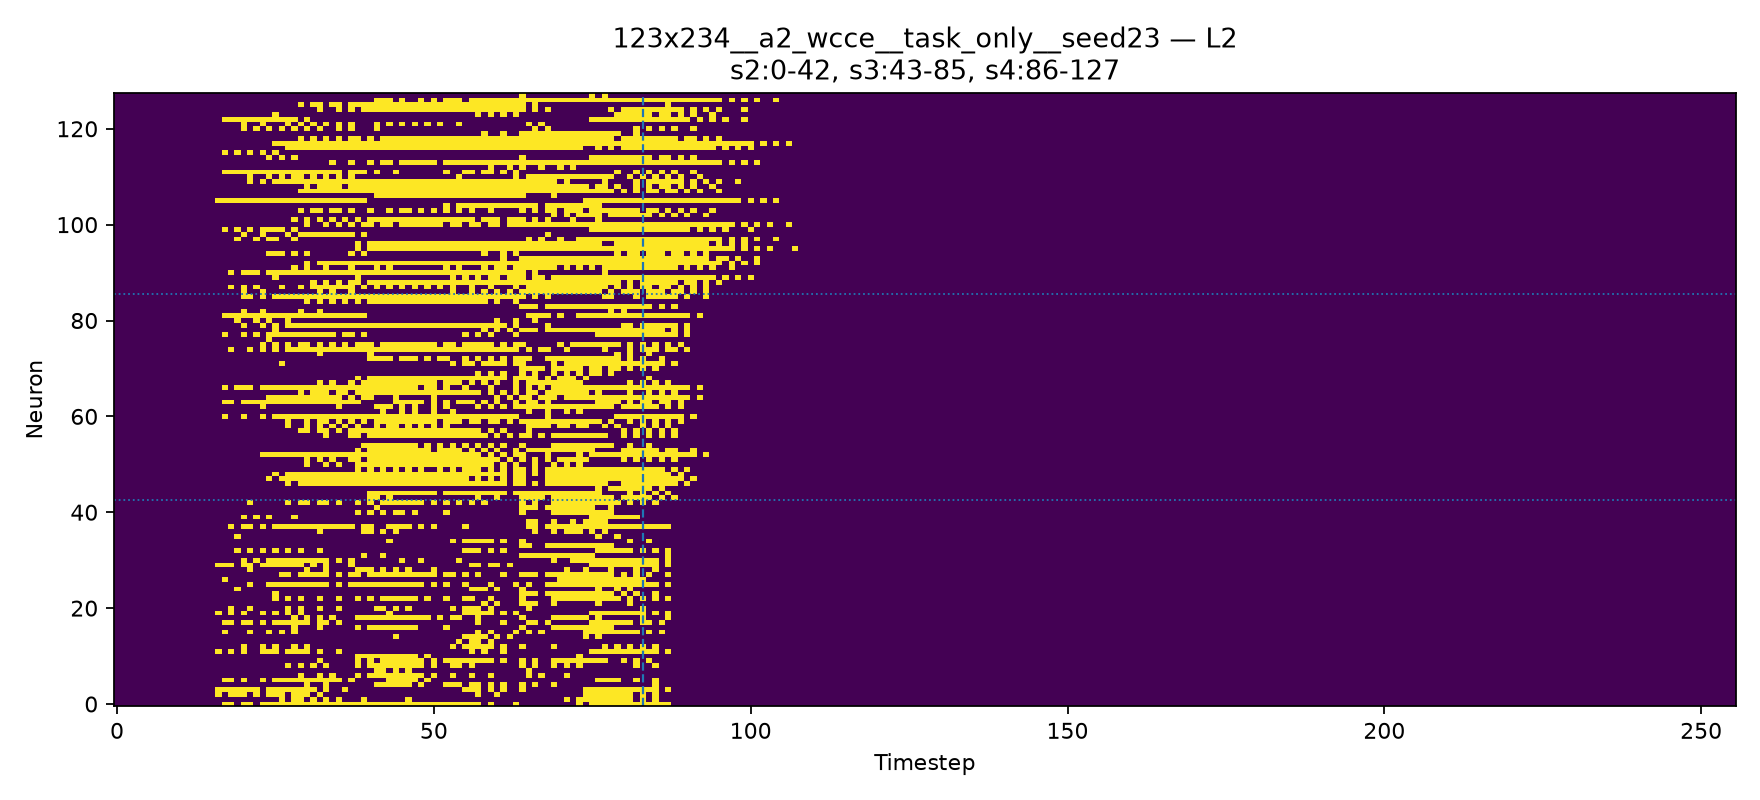

**OUTPUT**

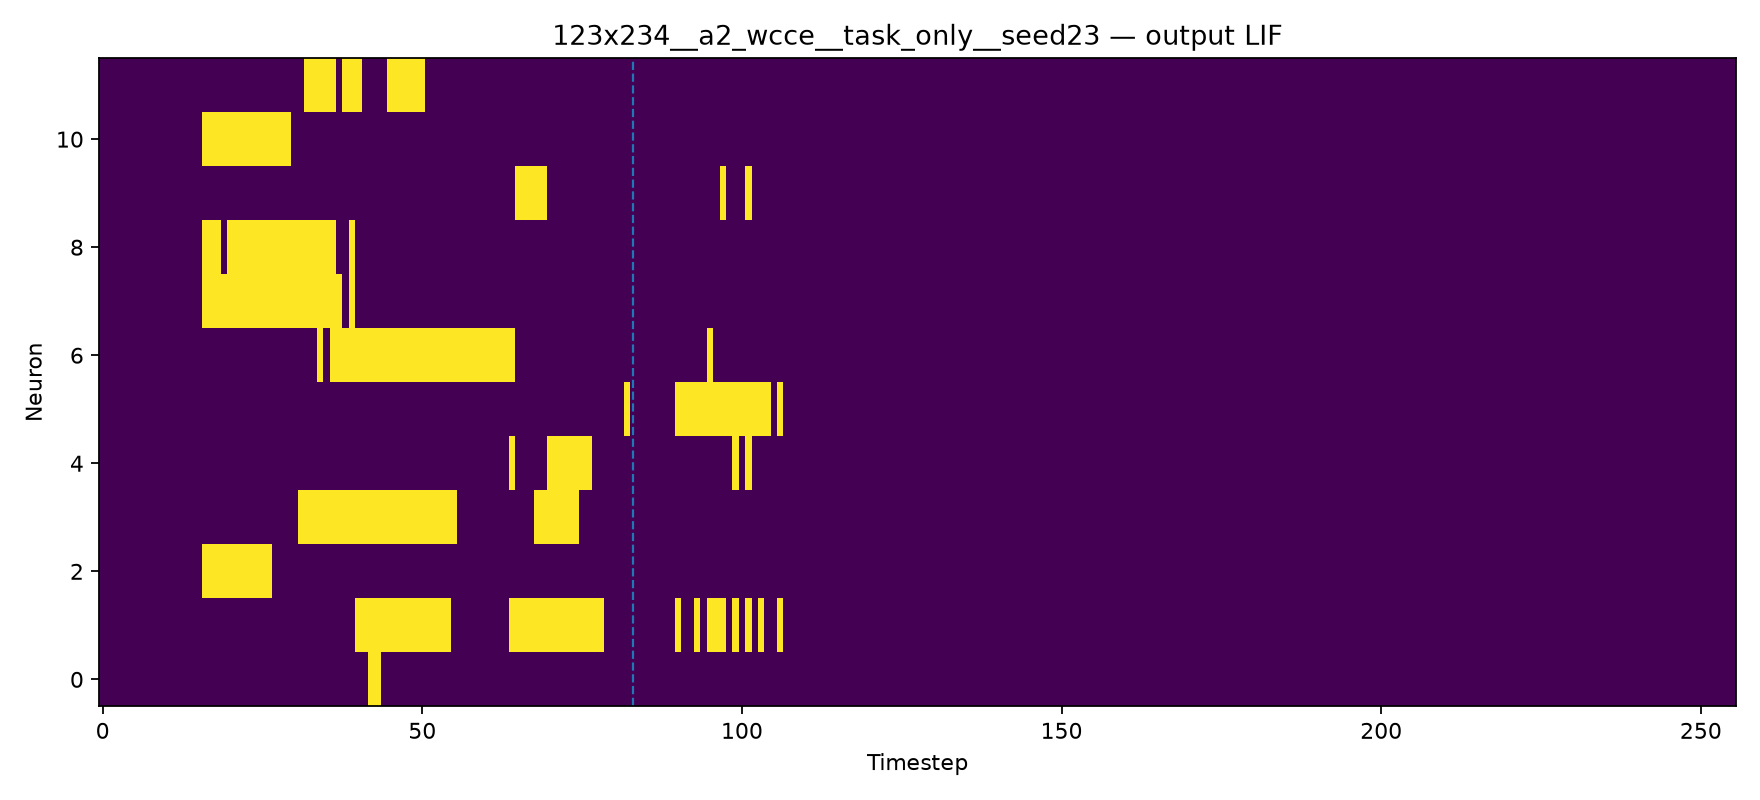

### 123x234 — seed 37

**L1**

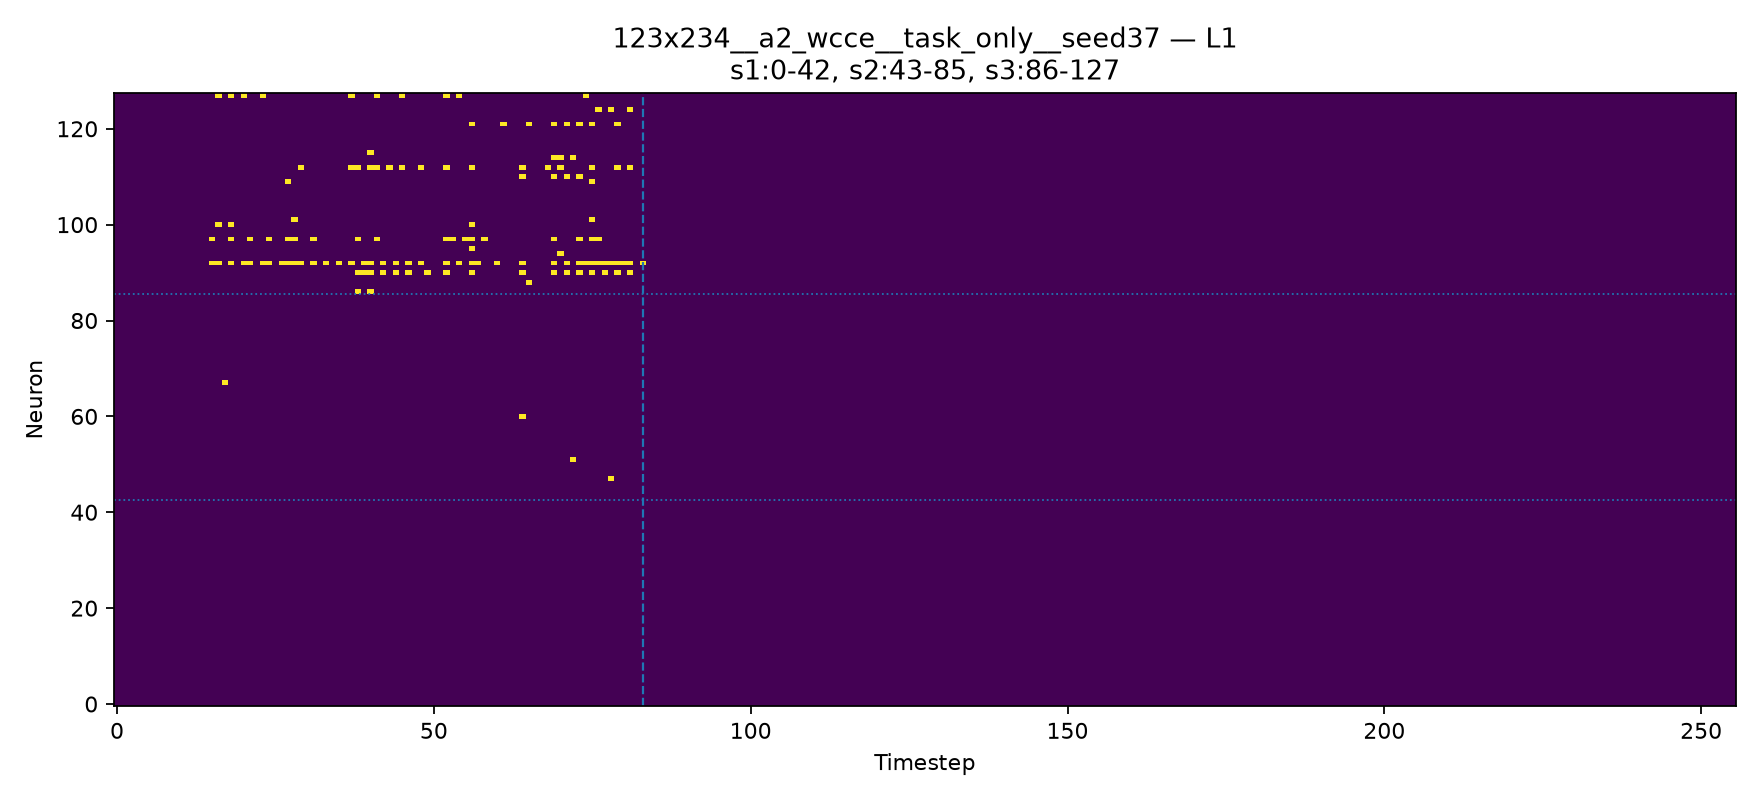

**L2**

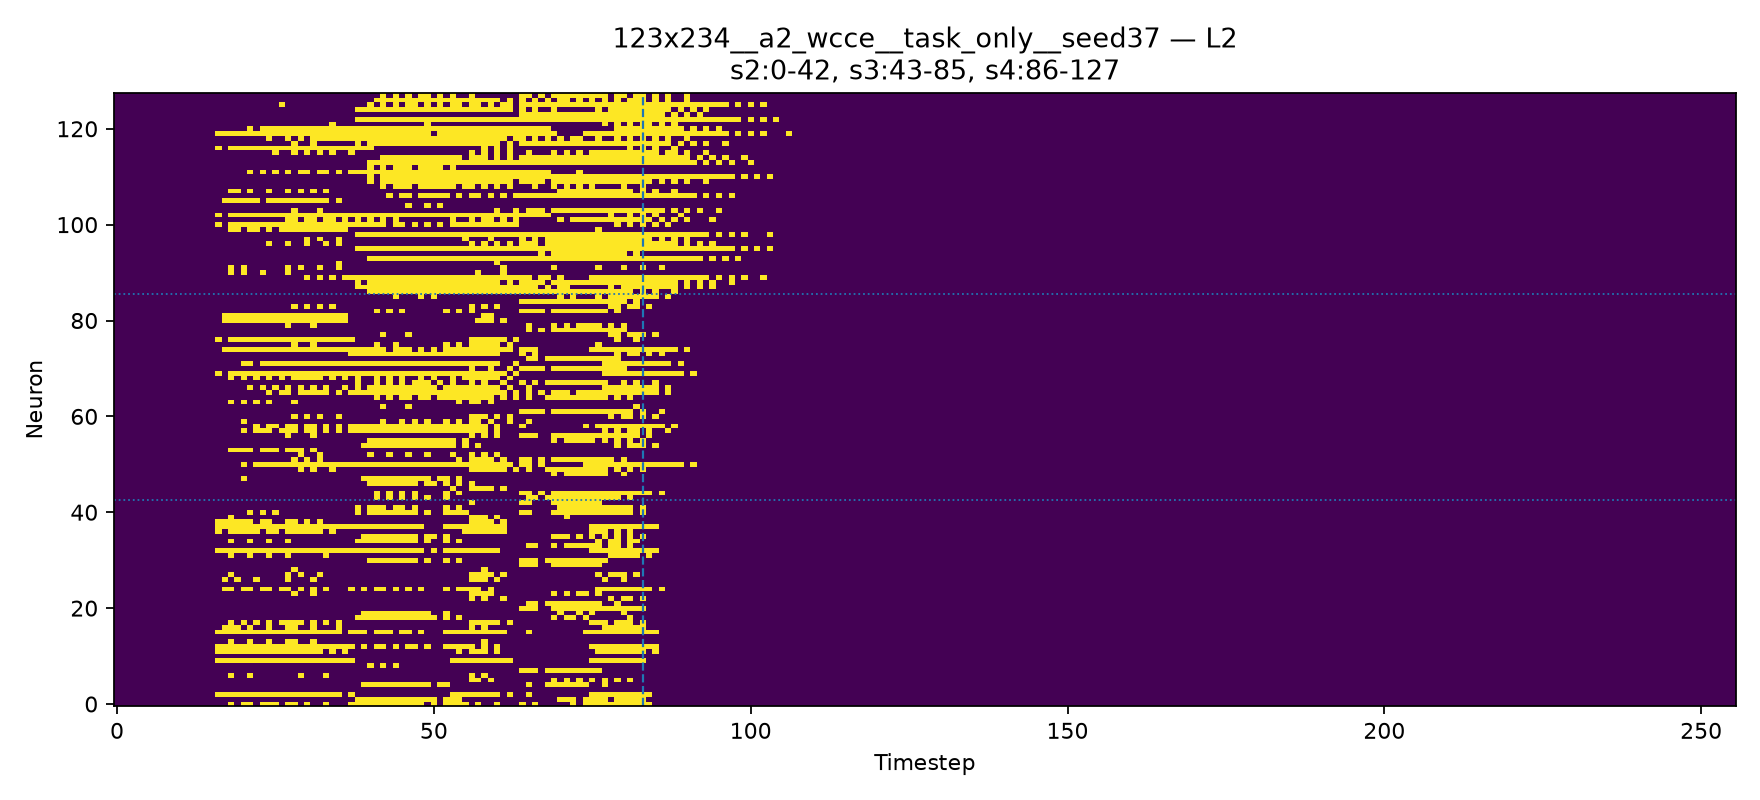

**OUTPUT**

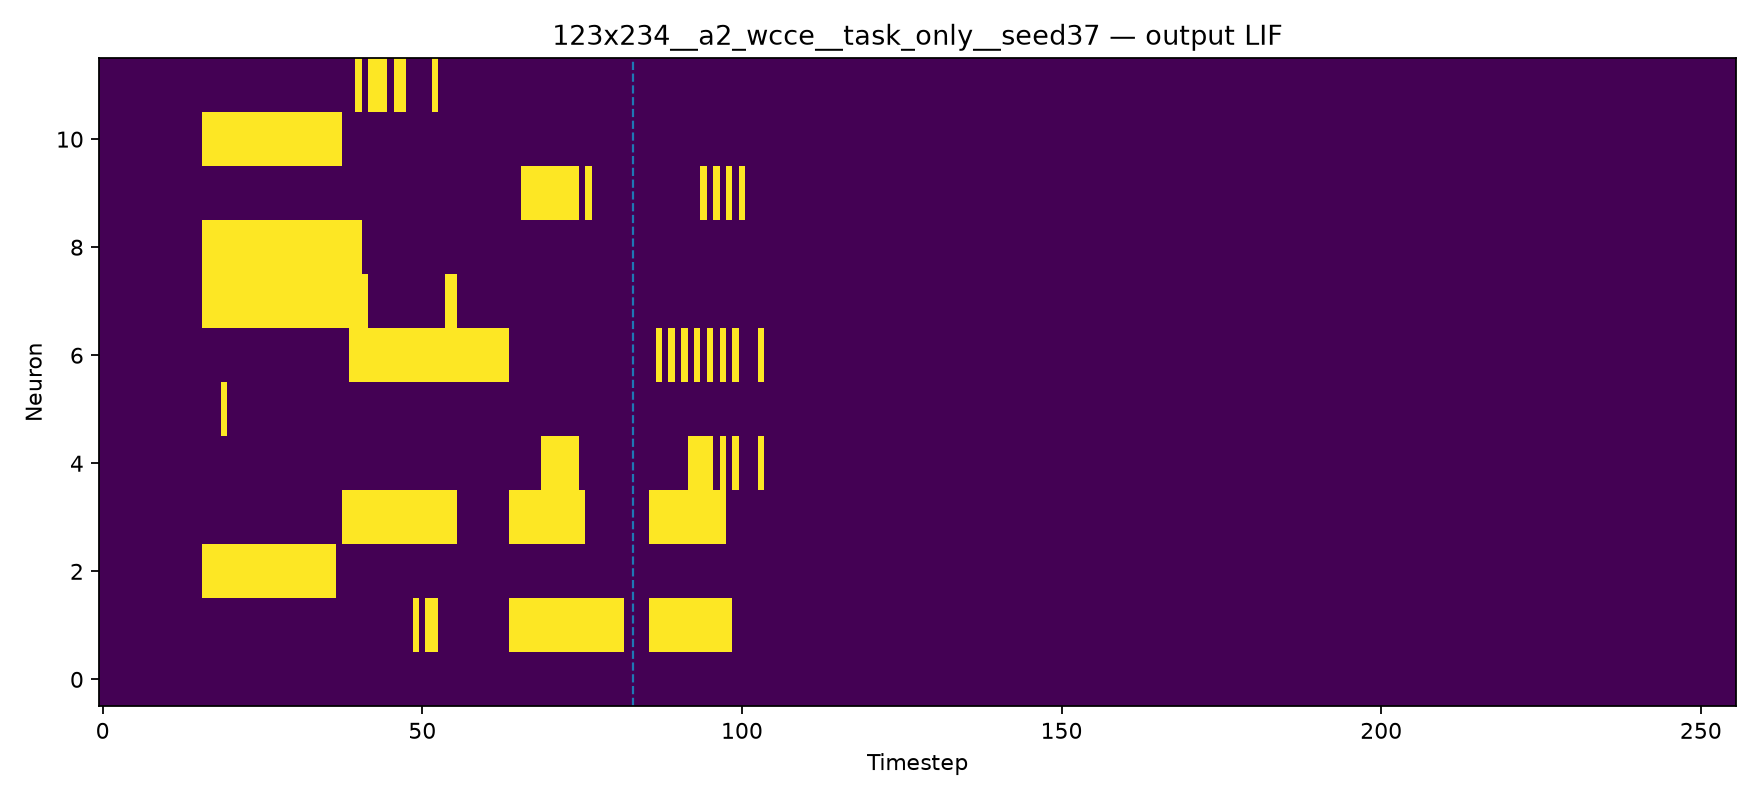

### 123x345 — seed 11

**L1**

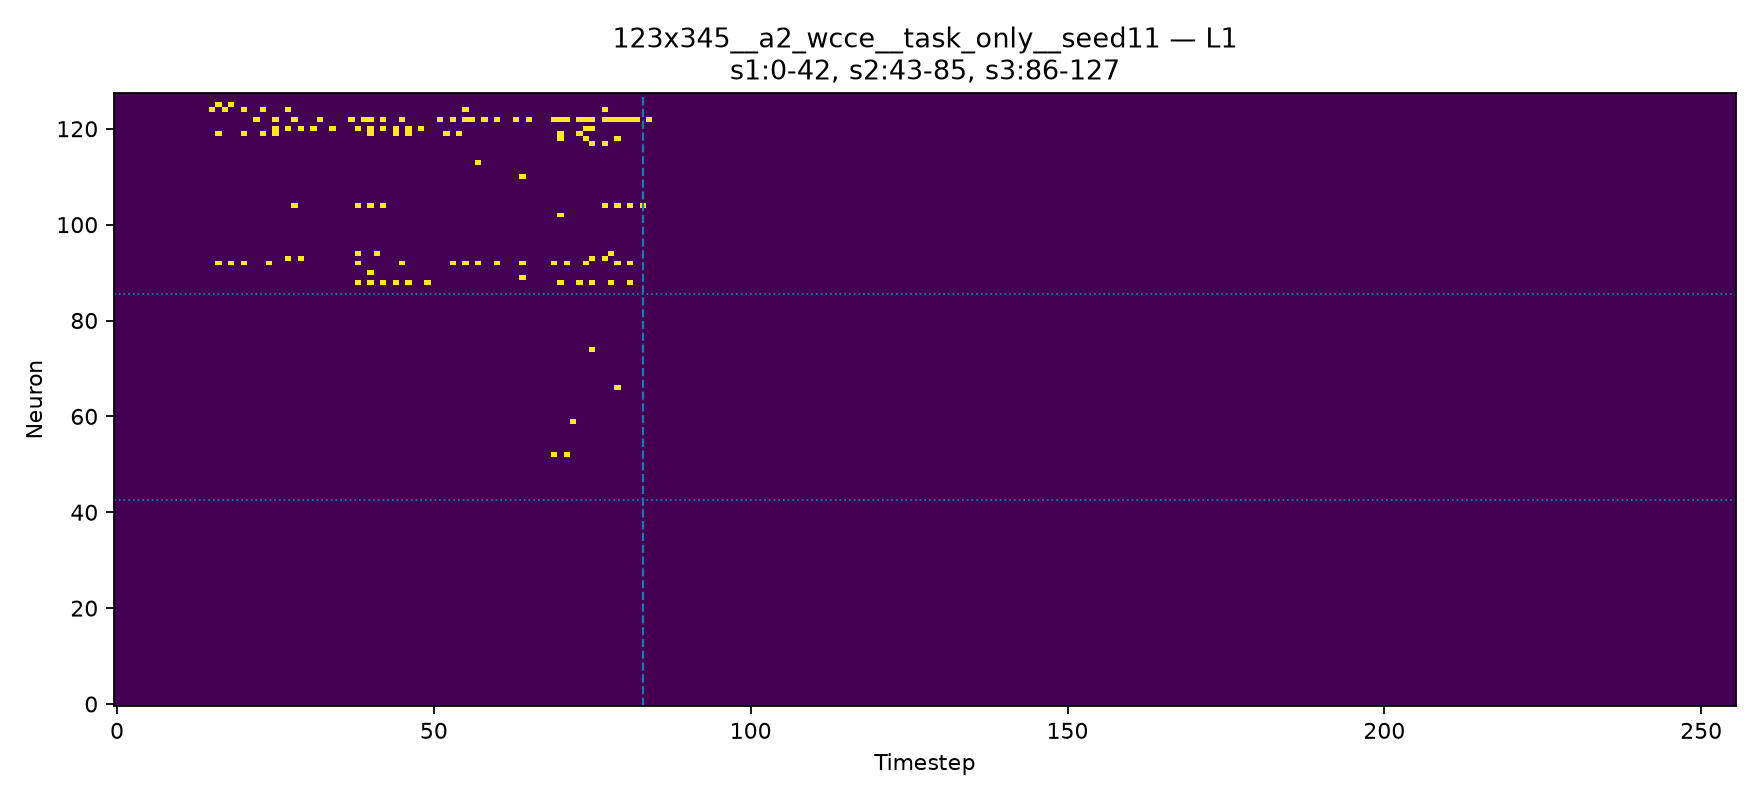

**L2**

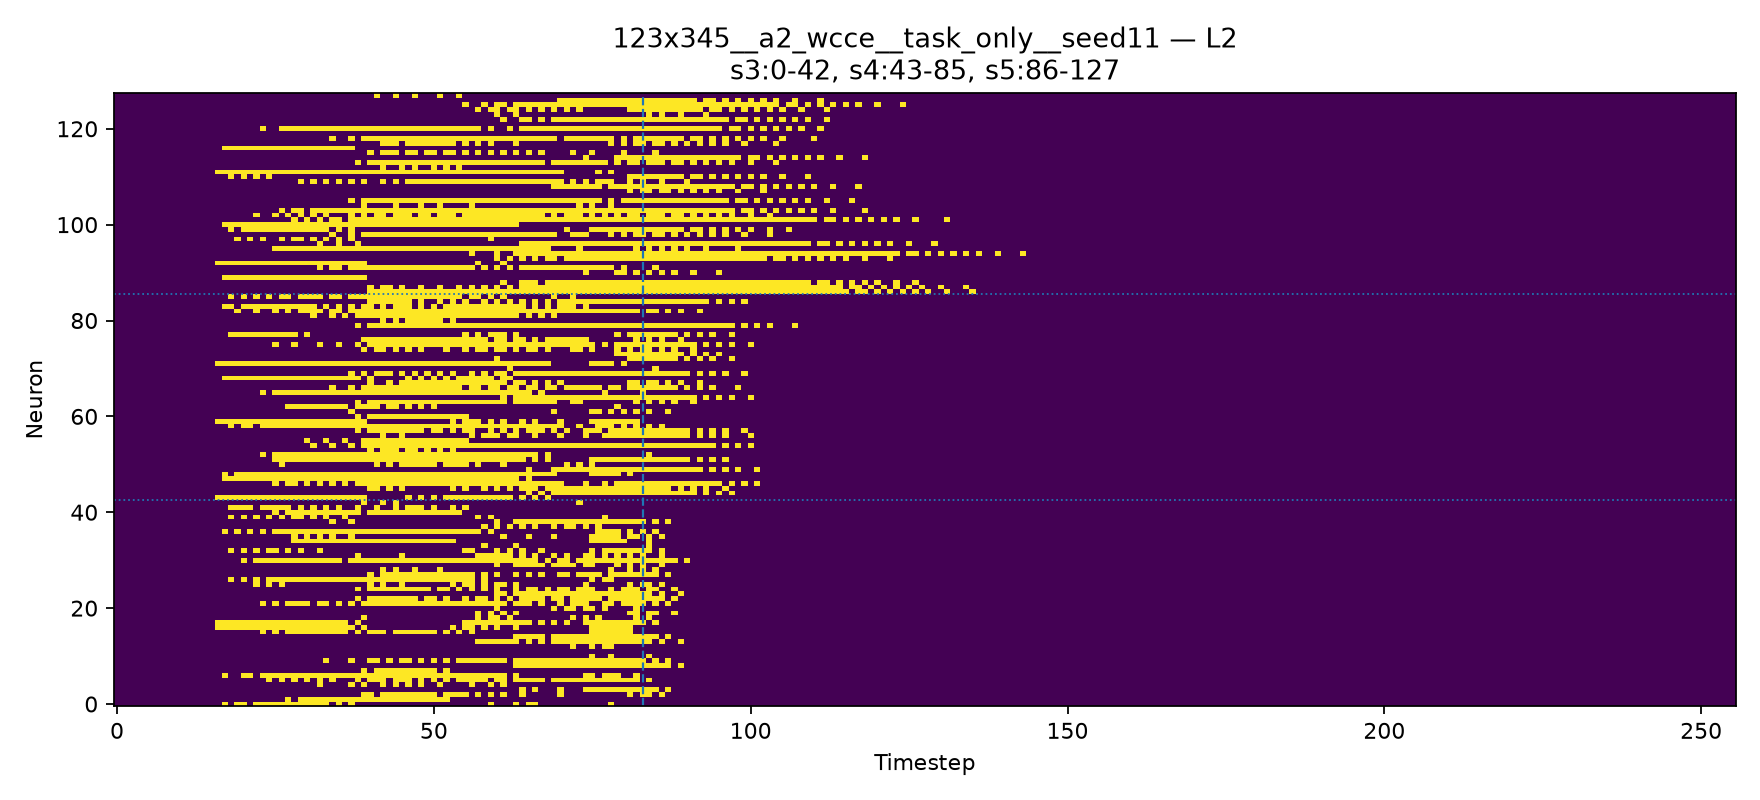

**OUTPUT**

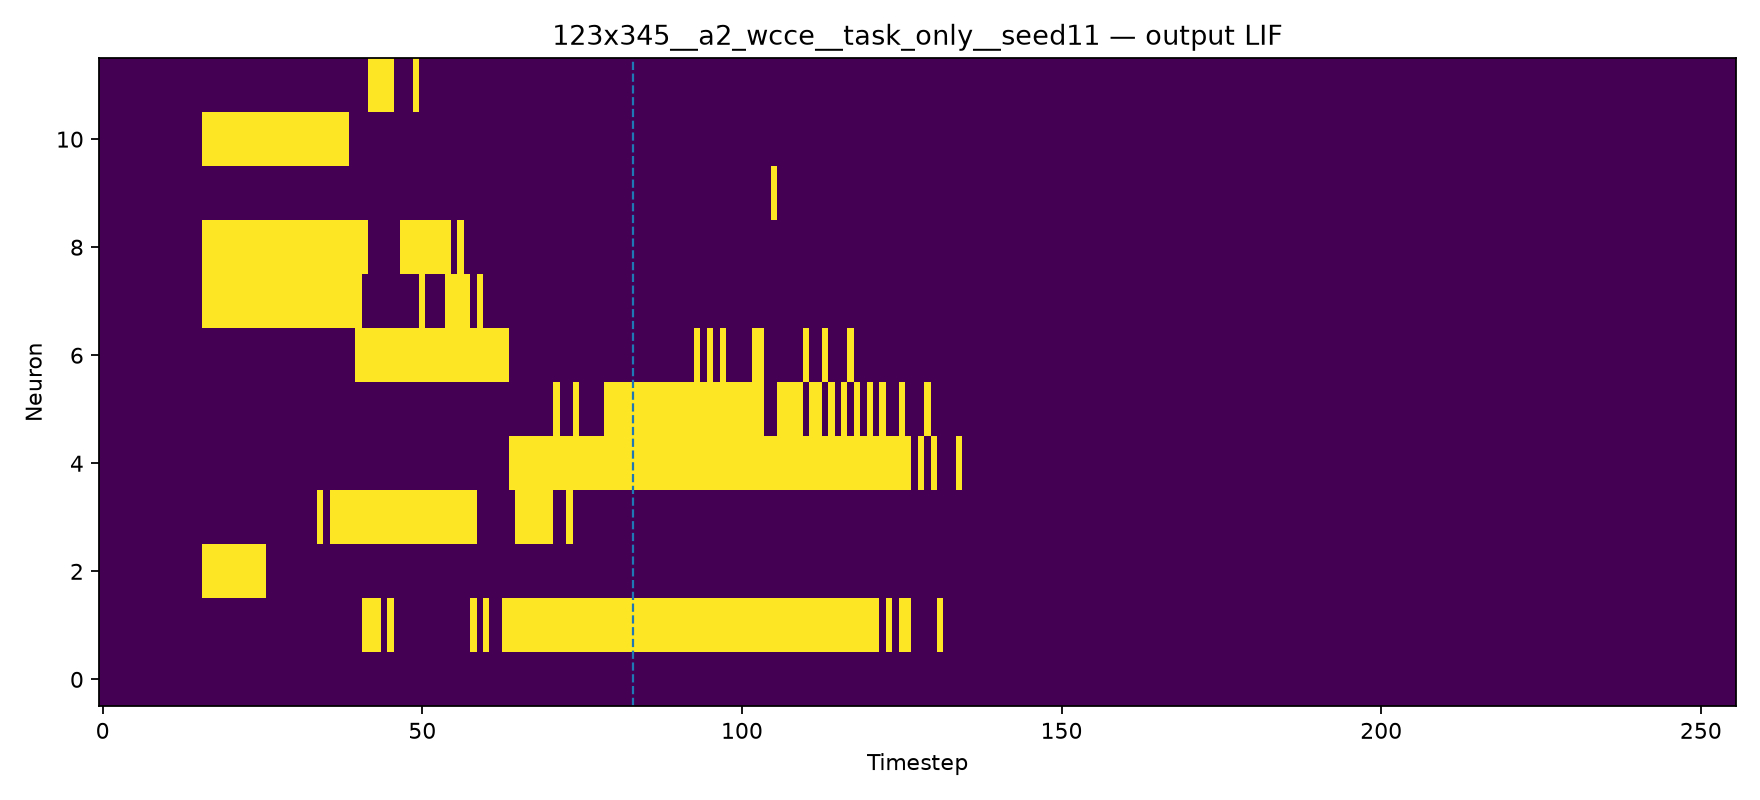

### 123x345 — seed 23

**L1**

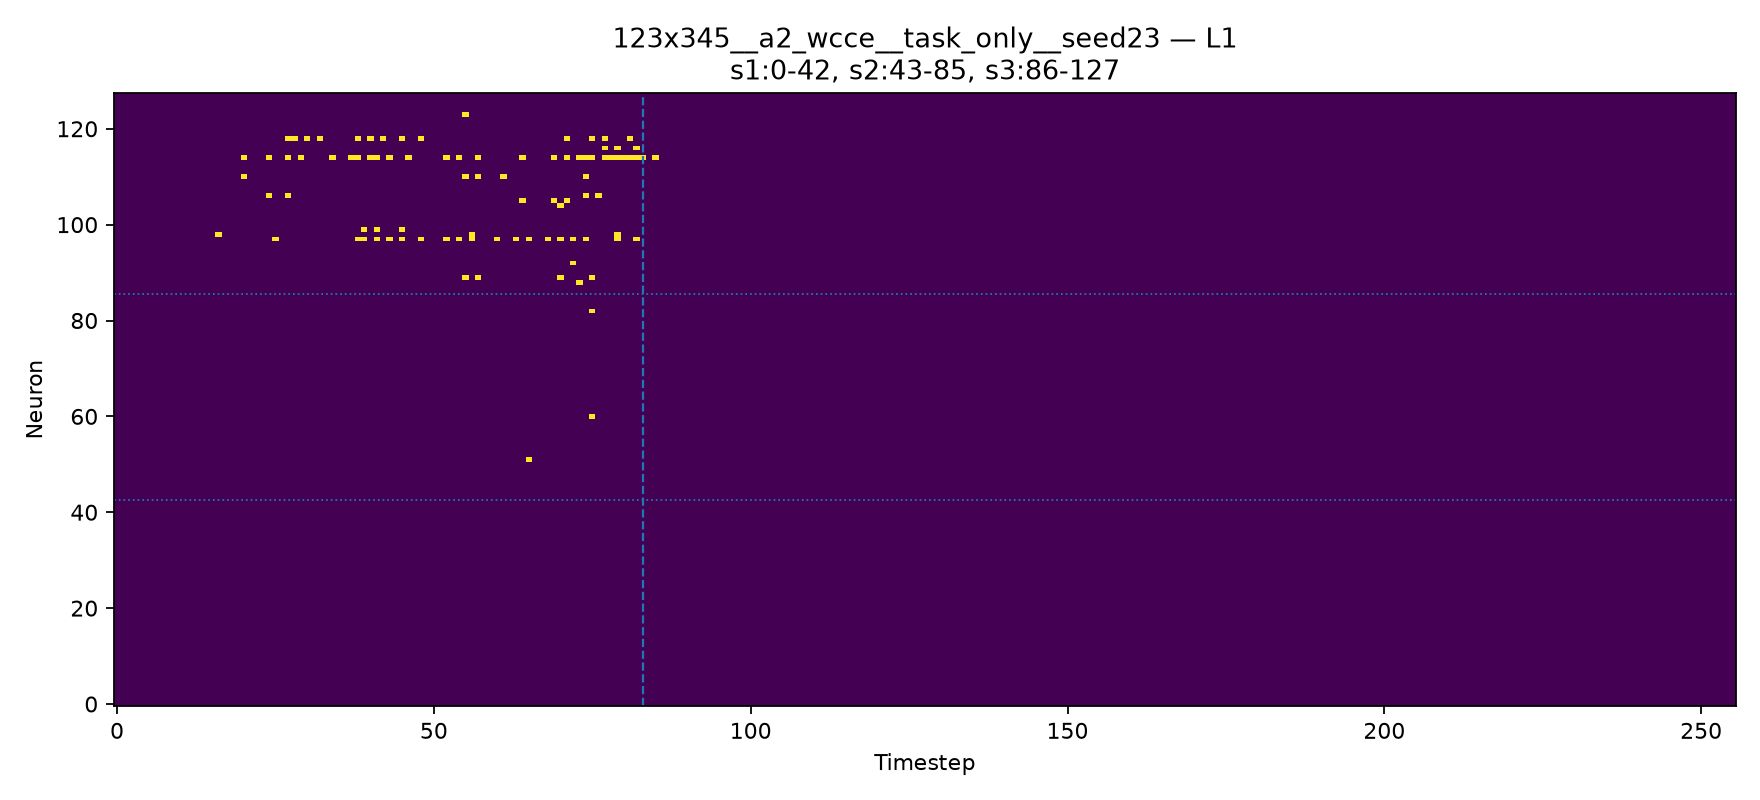

**L2**

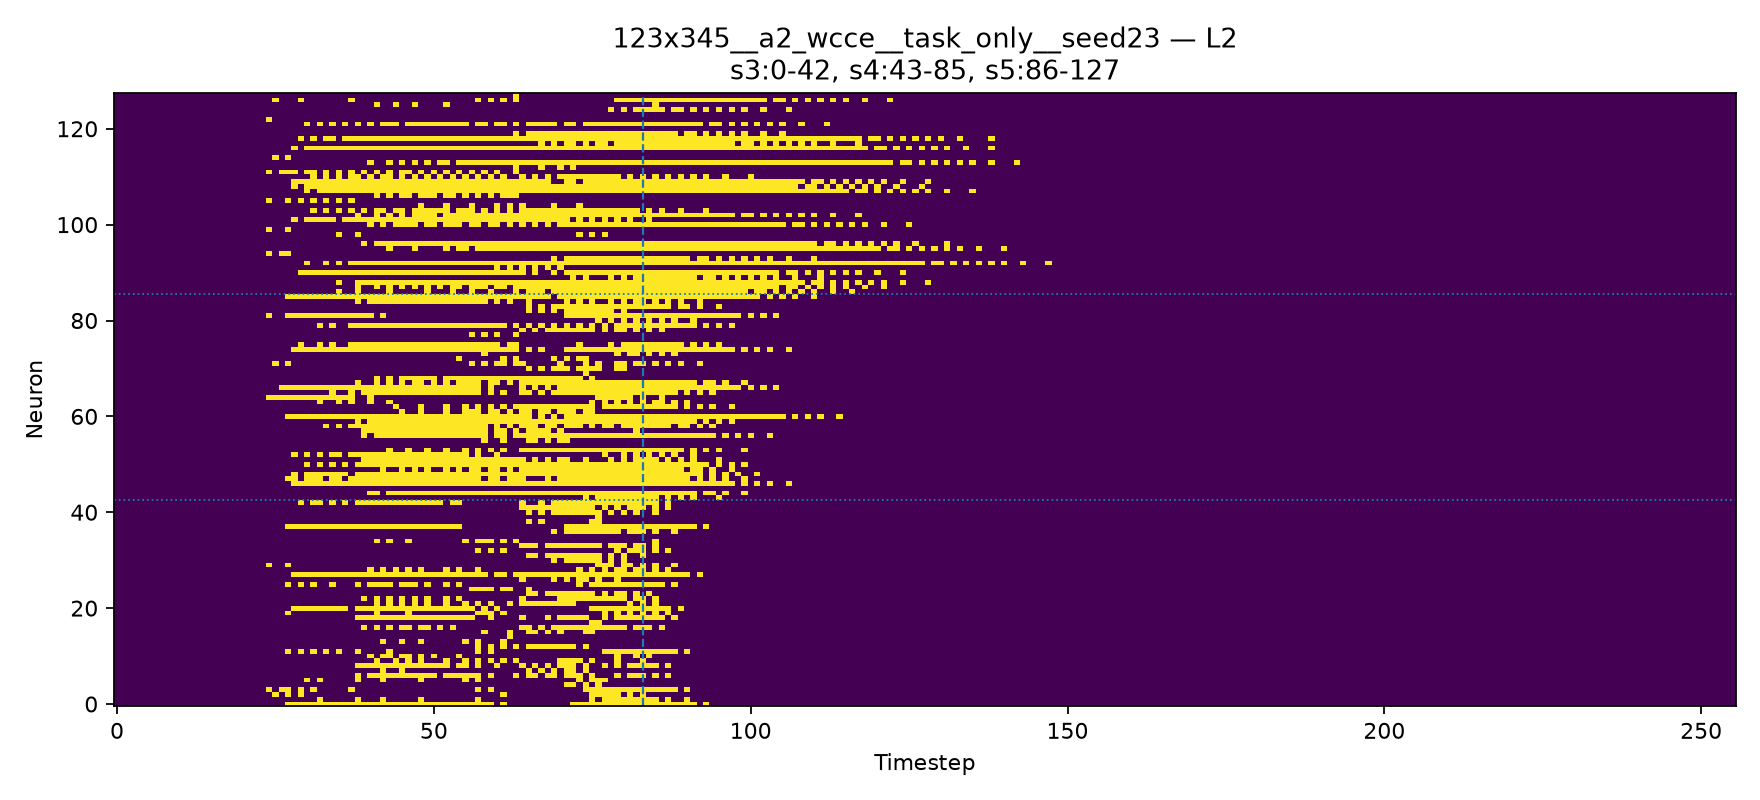

**OUTPUT**

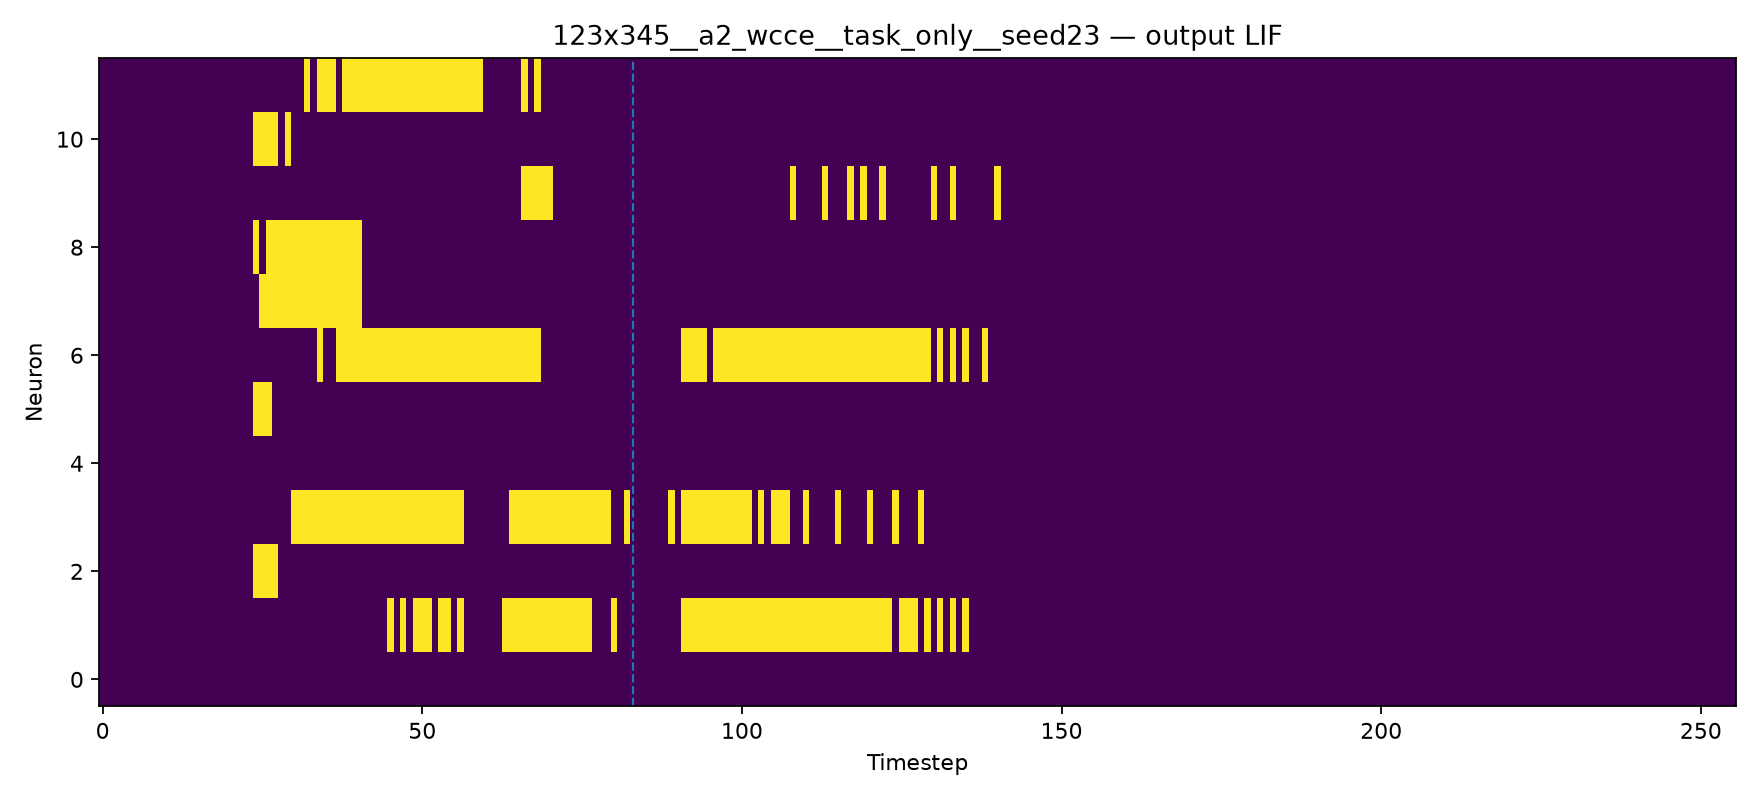

### 123x345 — seed 37

**L1**

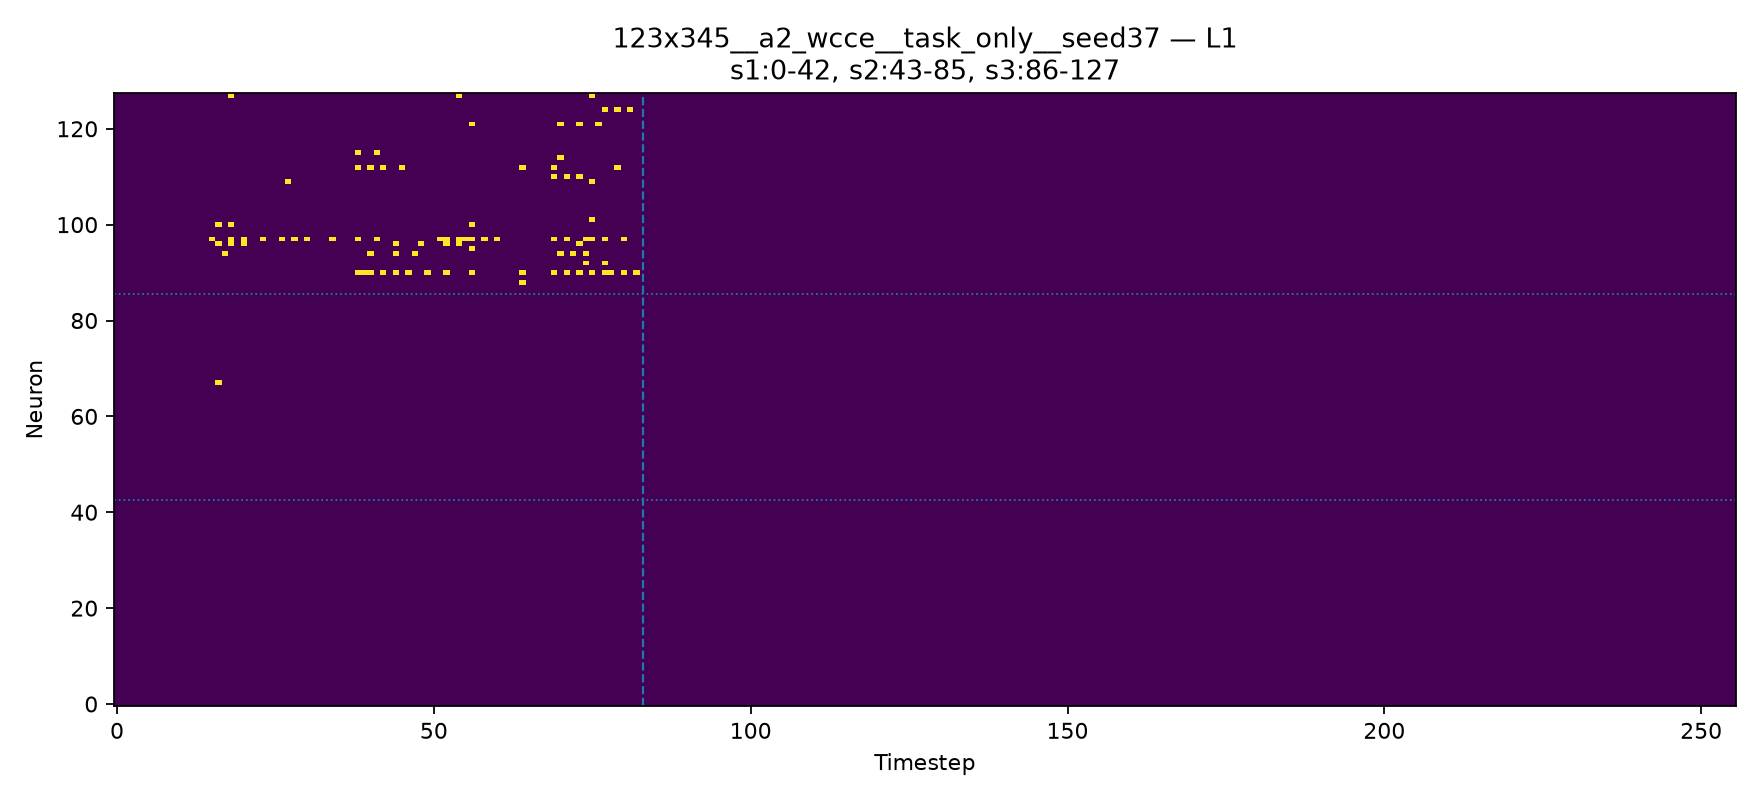

**L2**

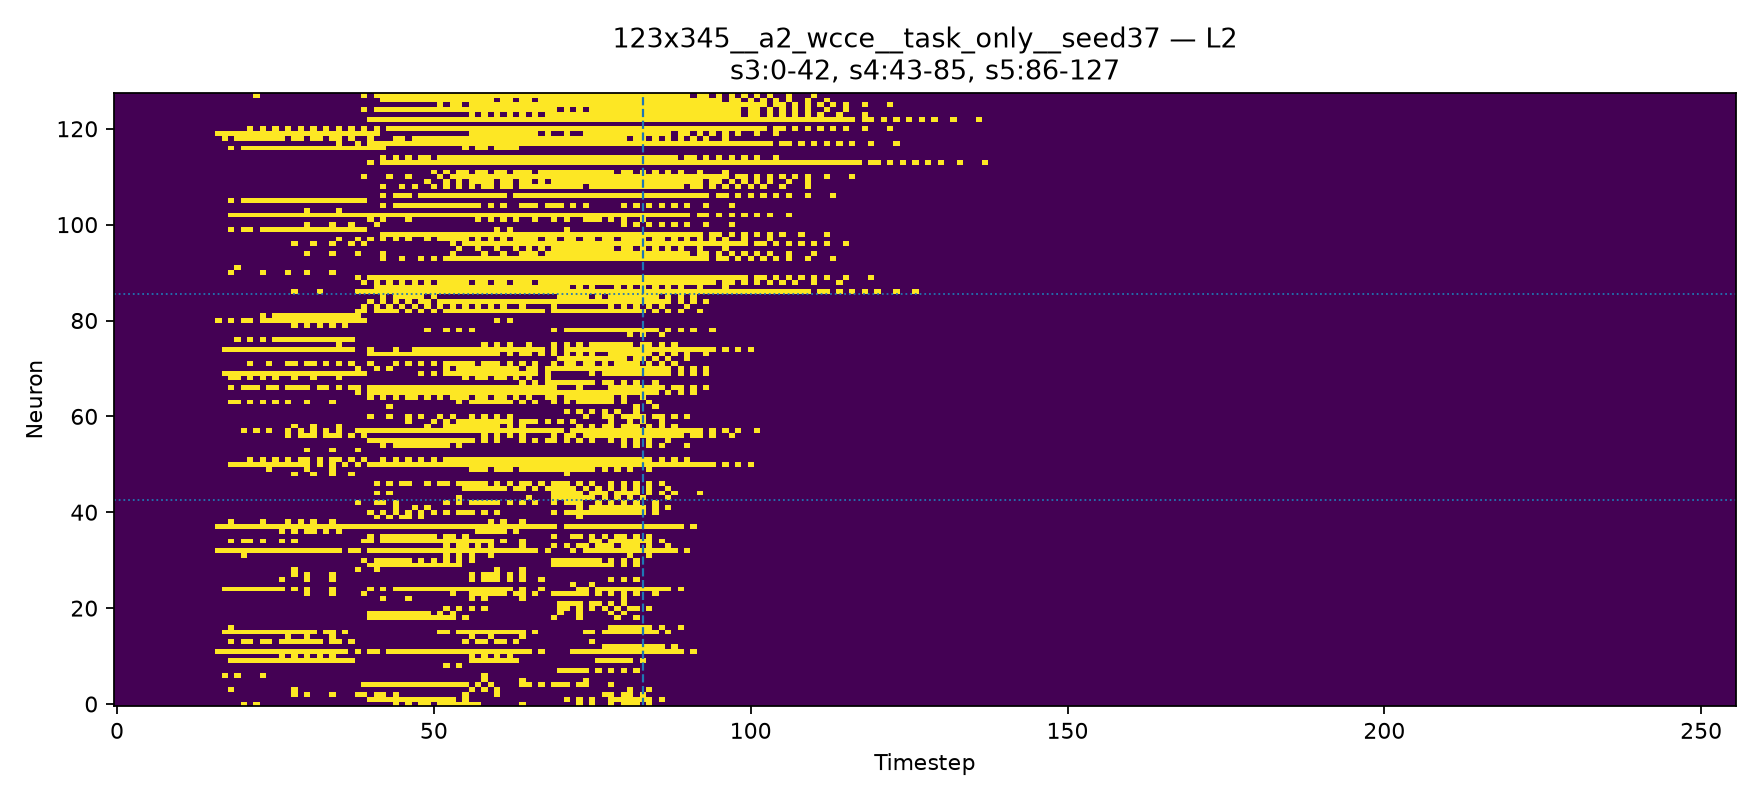

**OUTPUT**

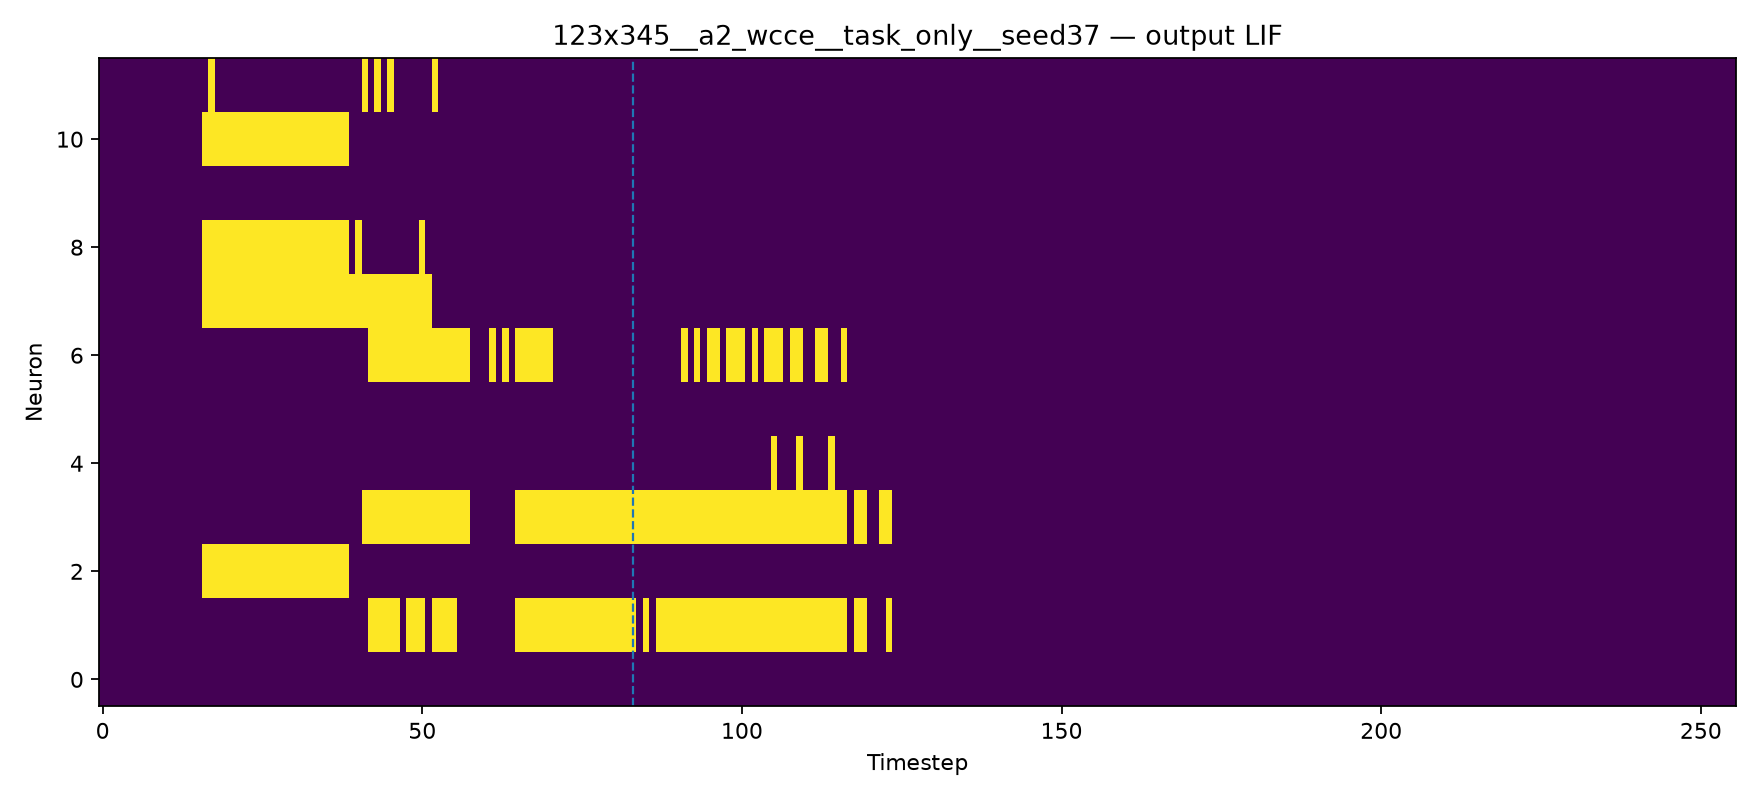

### 234x234 — seed 11

**L1**

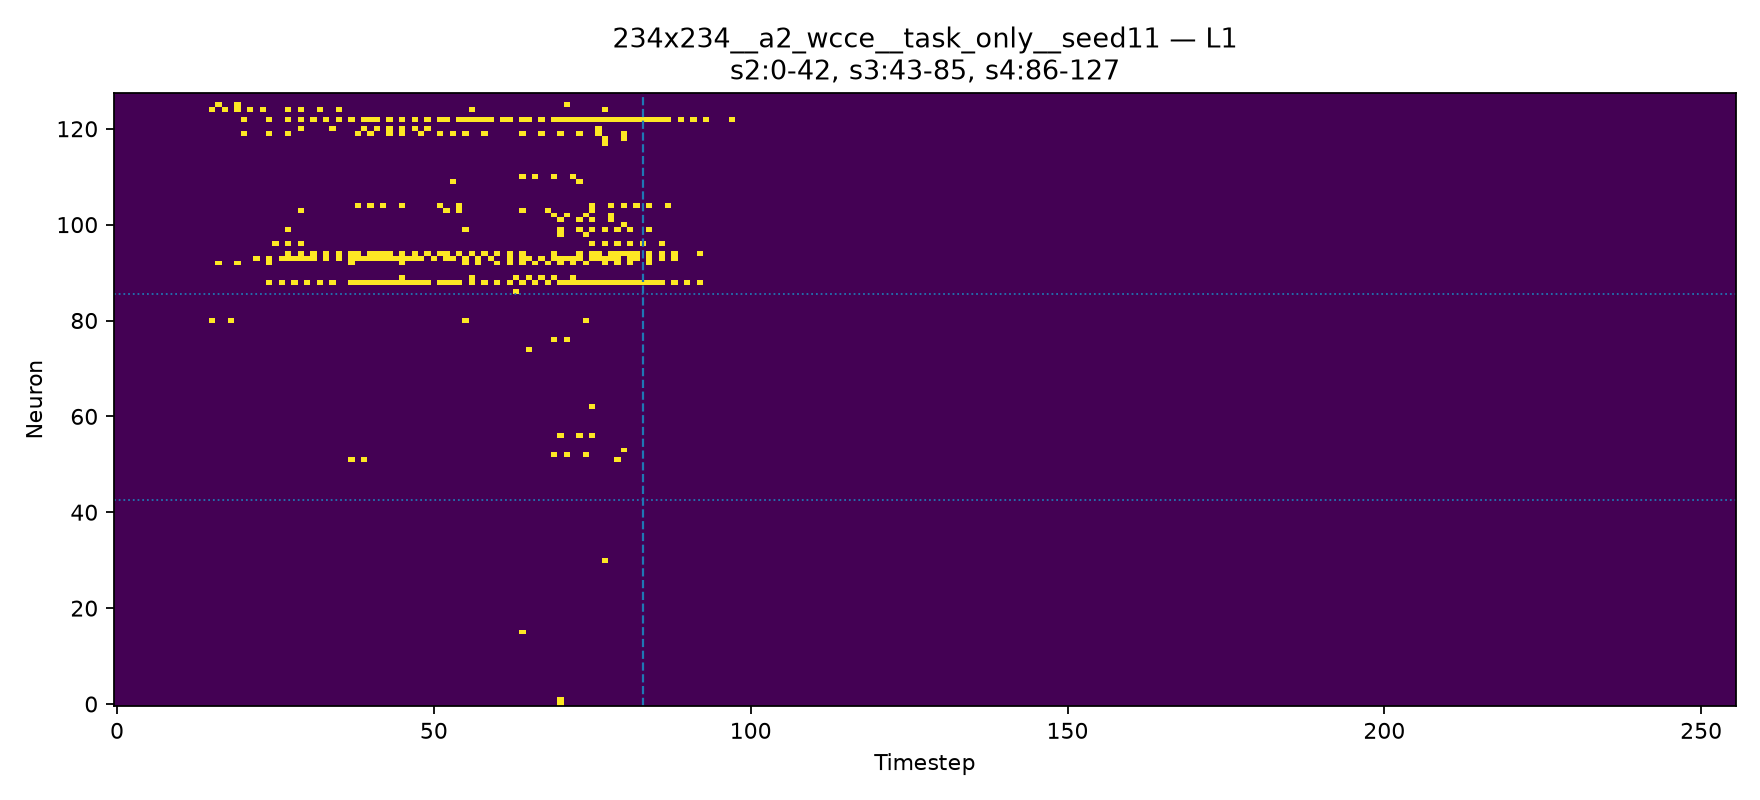

**L2**

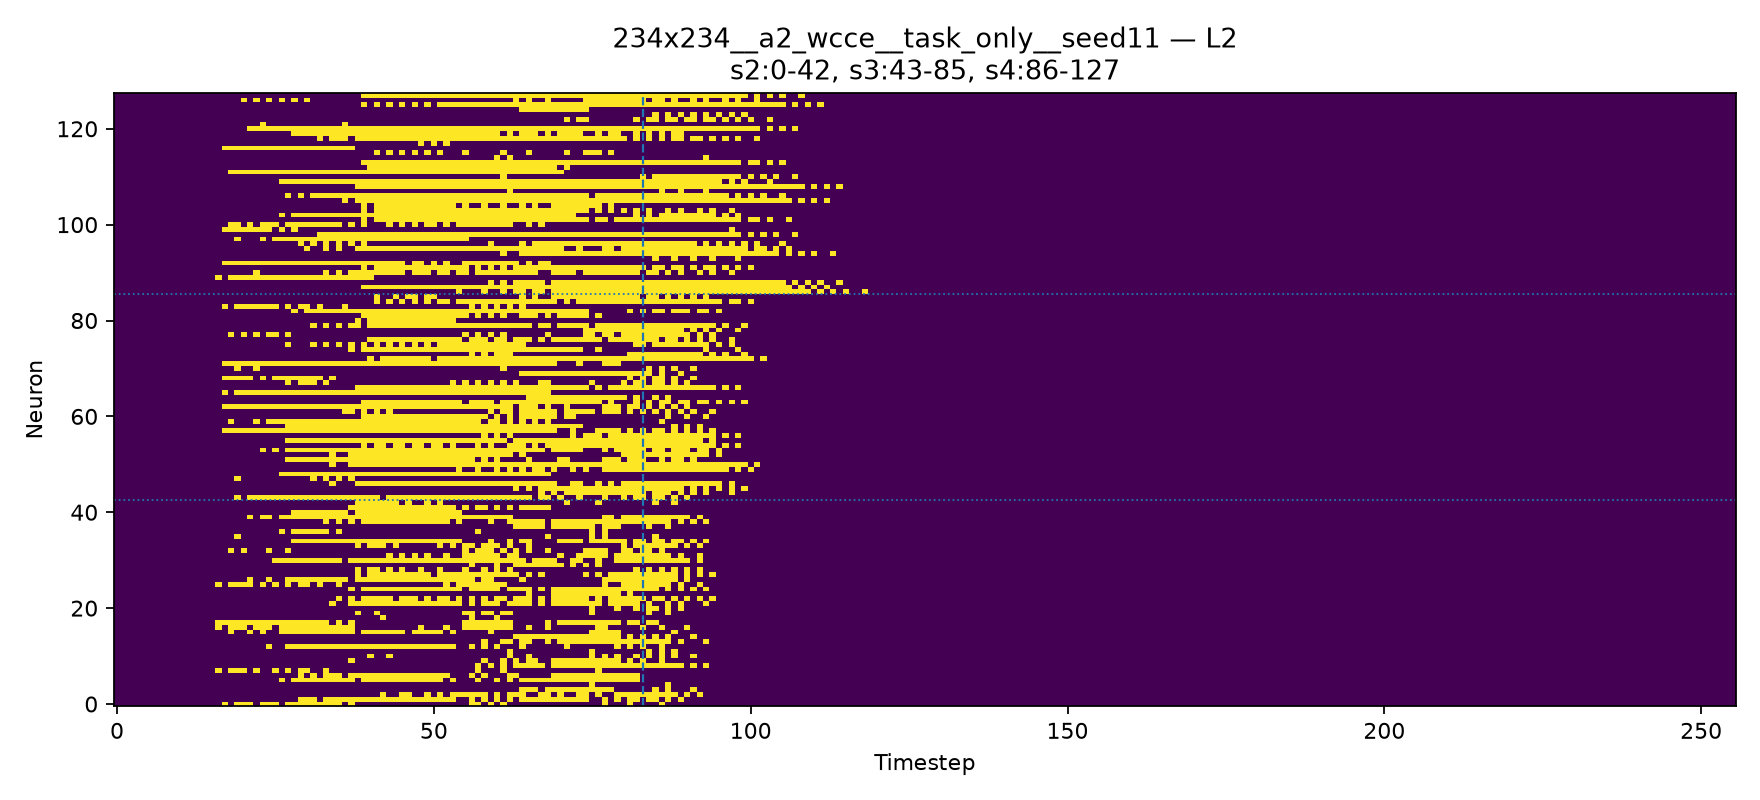

**OUTPUT**

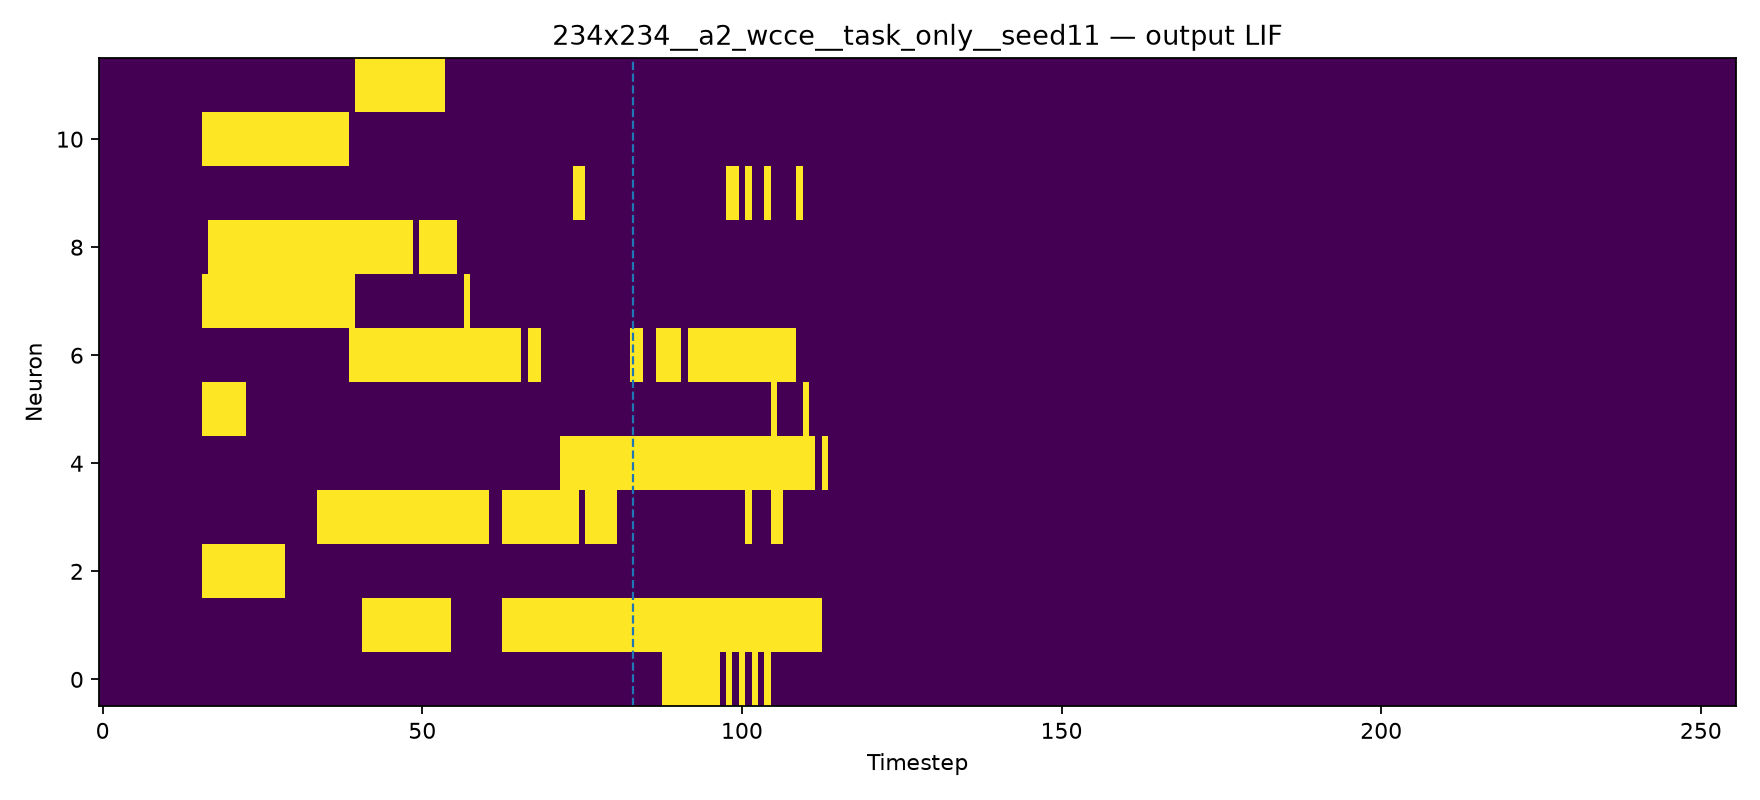

### 234x234 — seed 23

**L1**

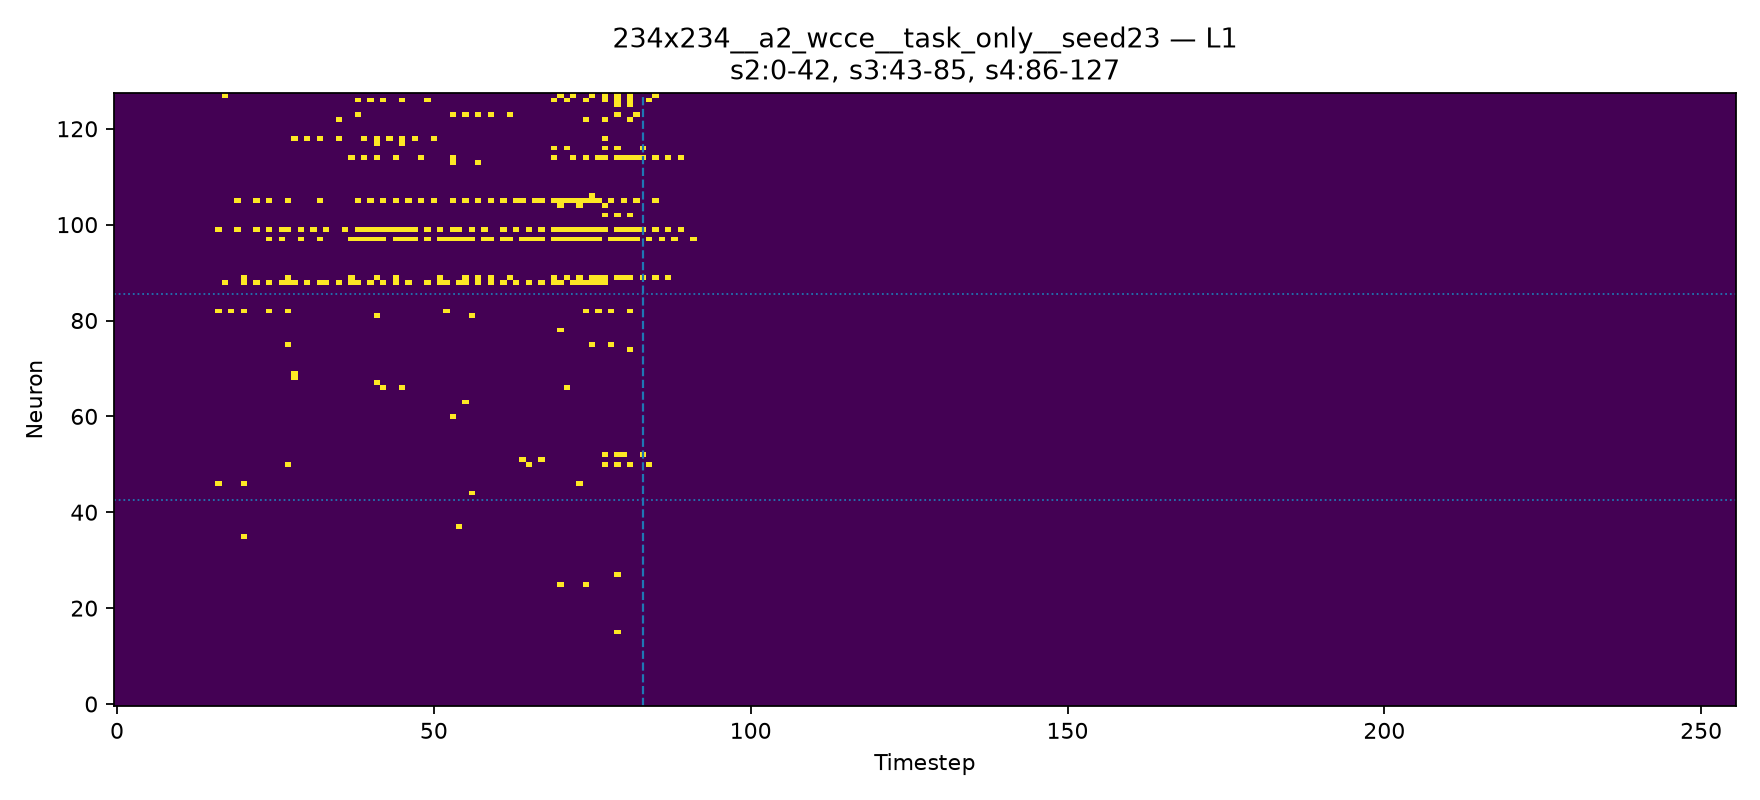

**L2**

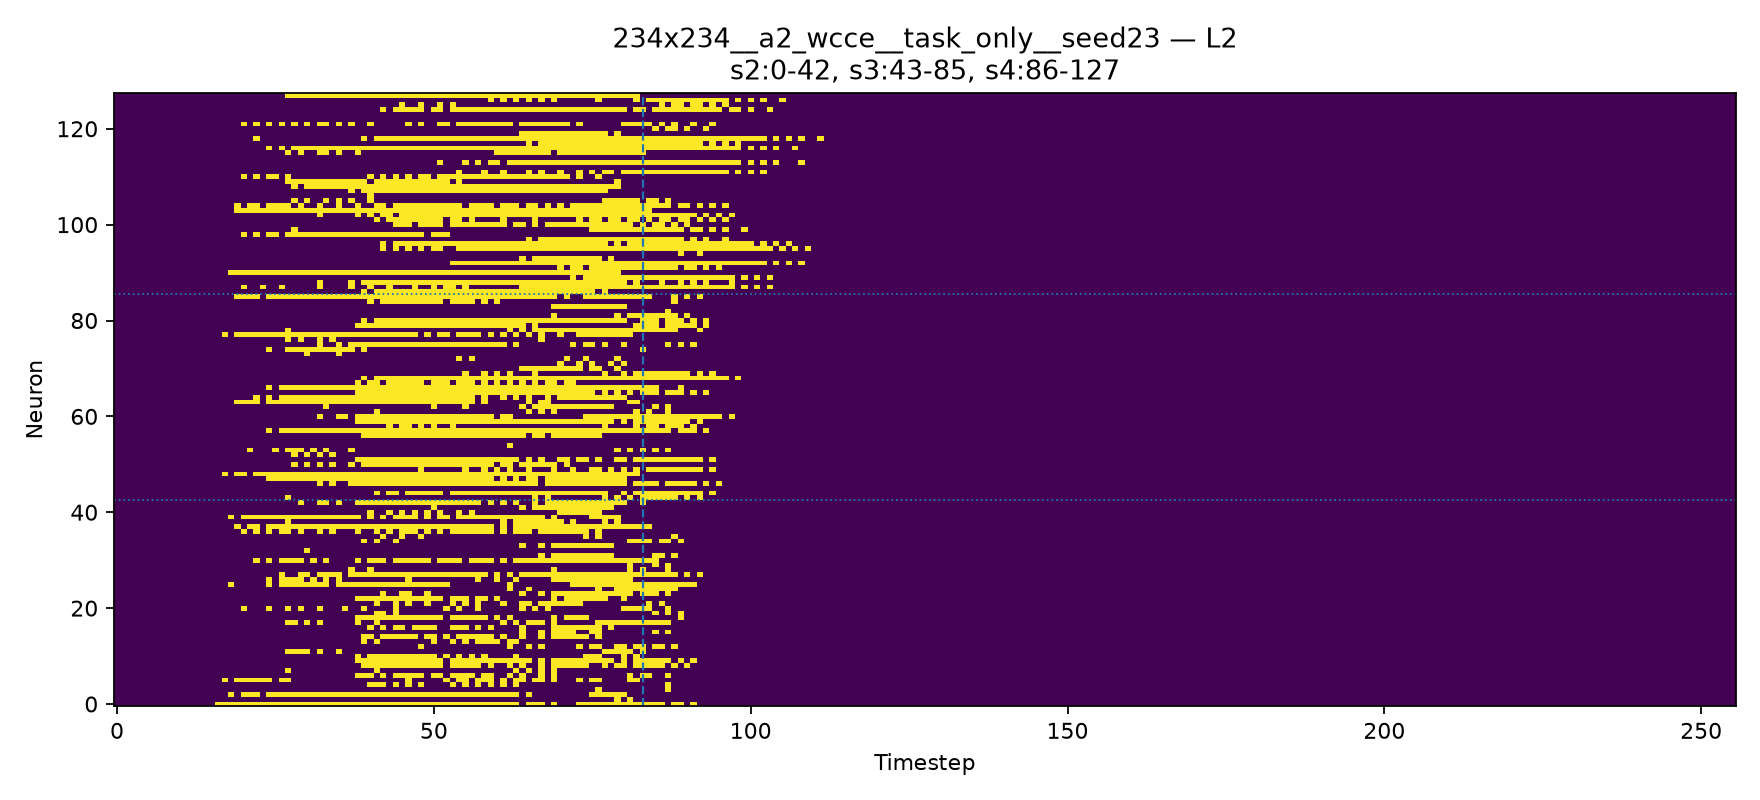

**OUTPUT**

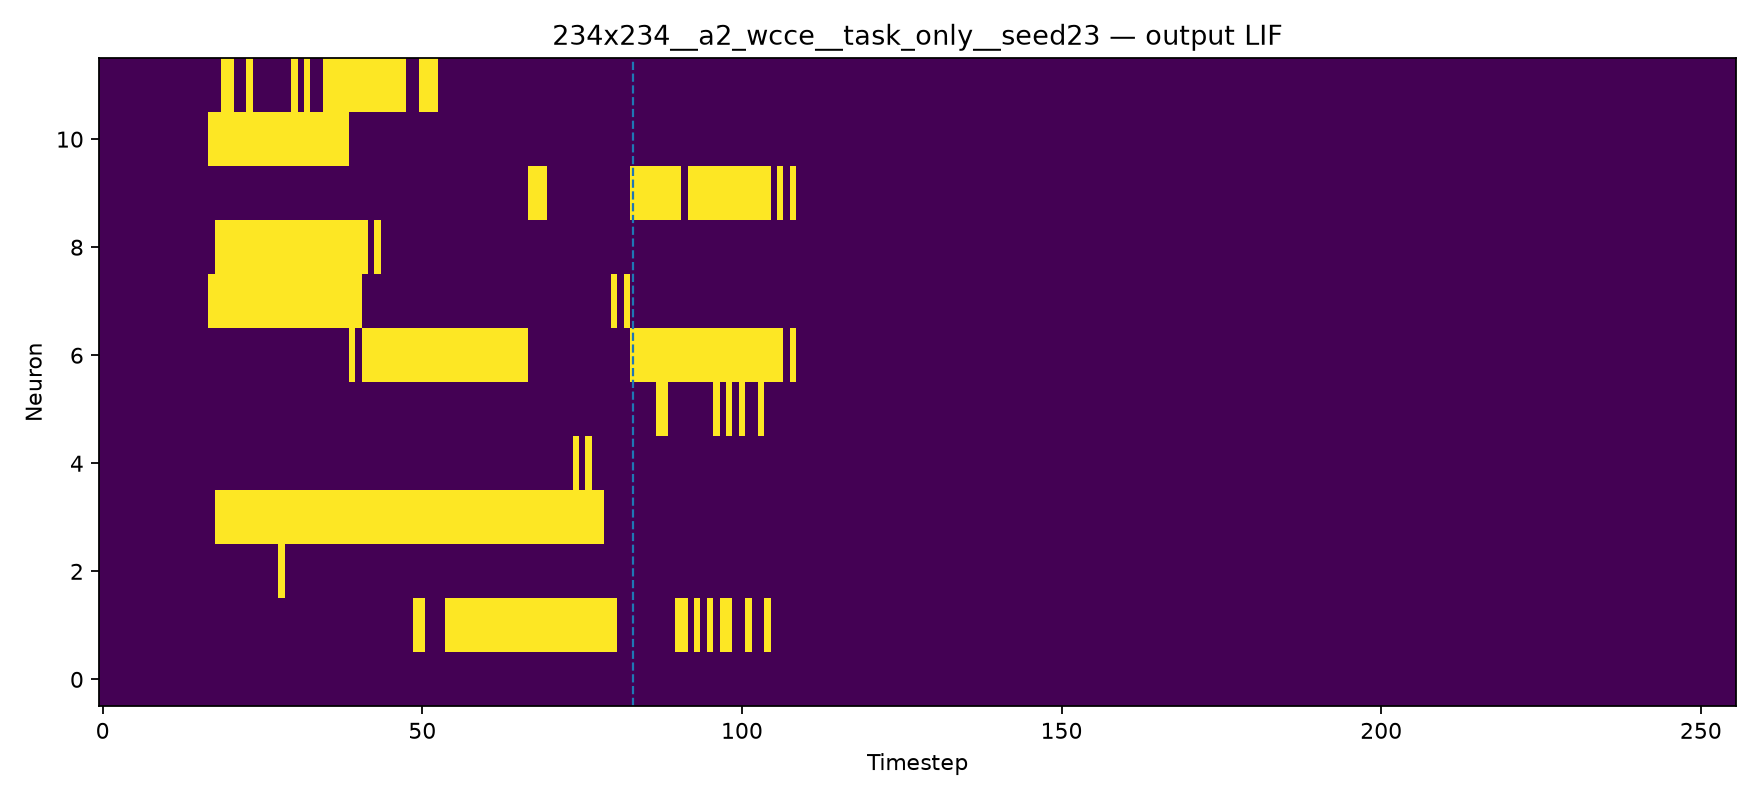

### 234x234 — seed 37

**L1**

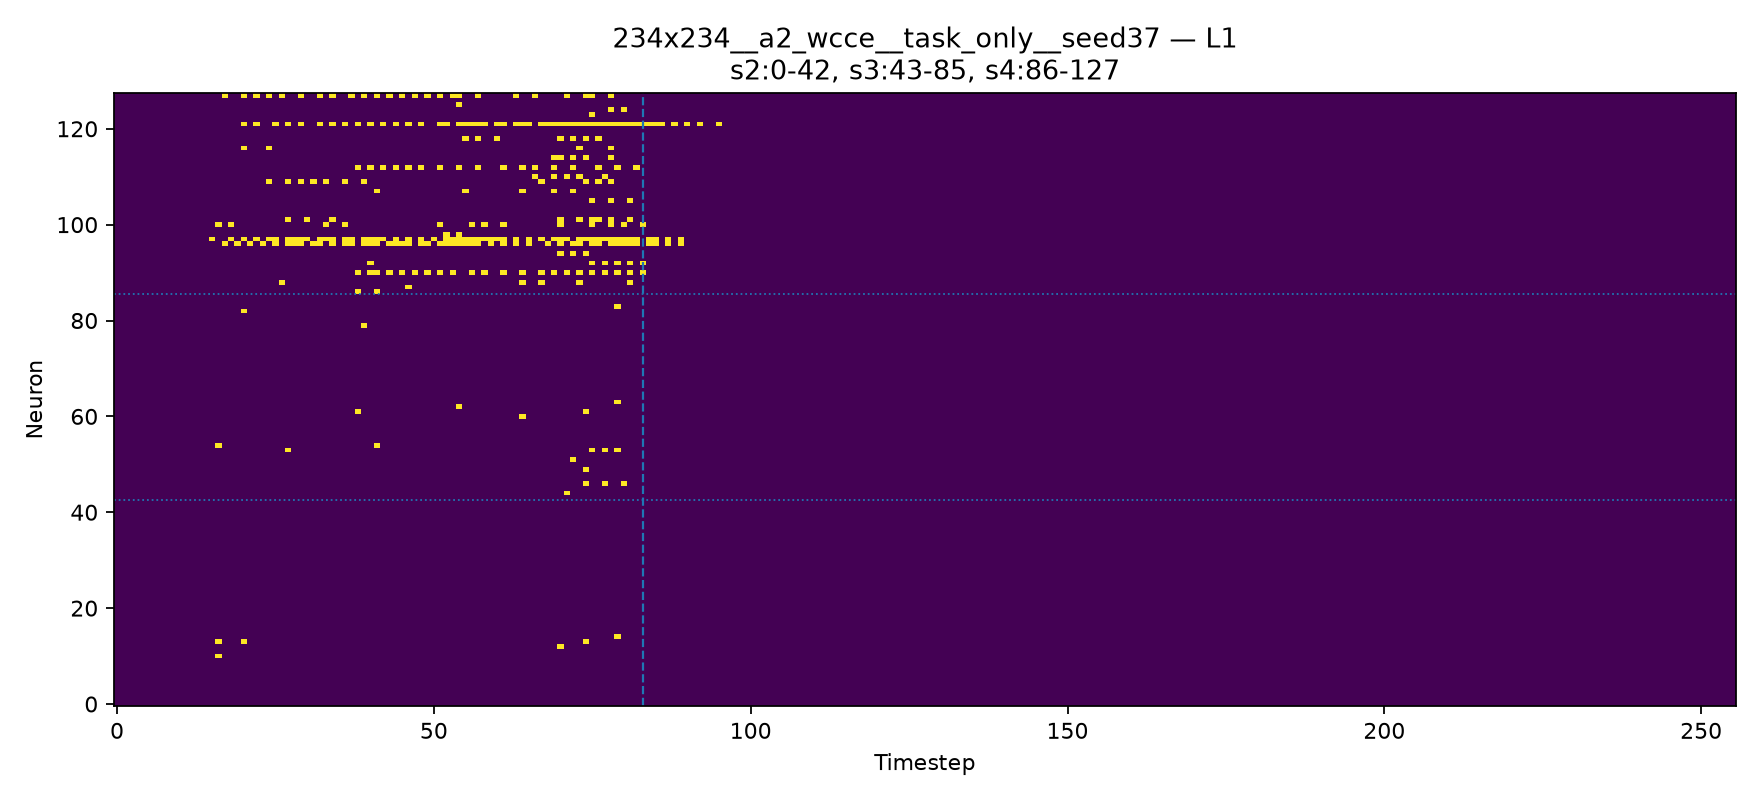

**L2**

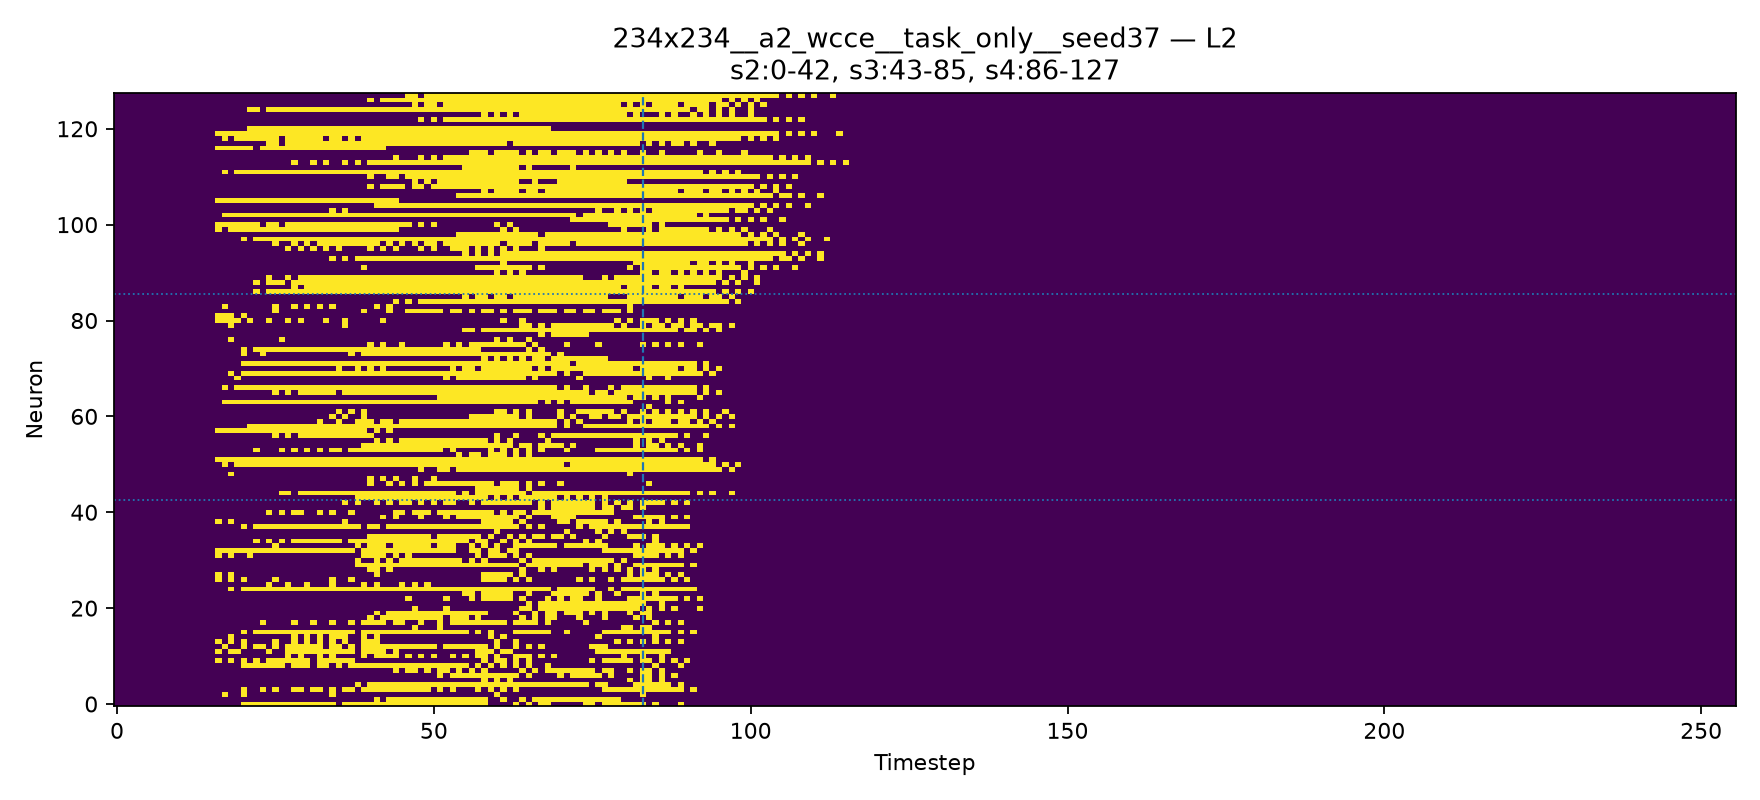

**OUTPUT**

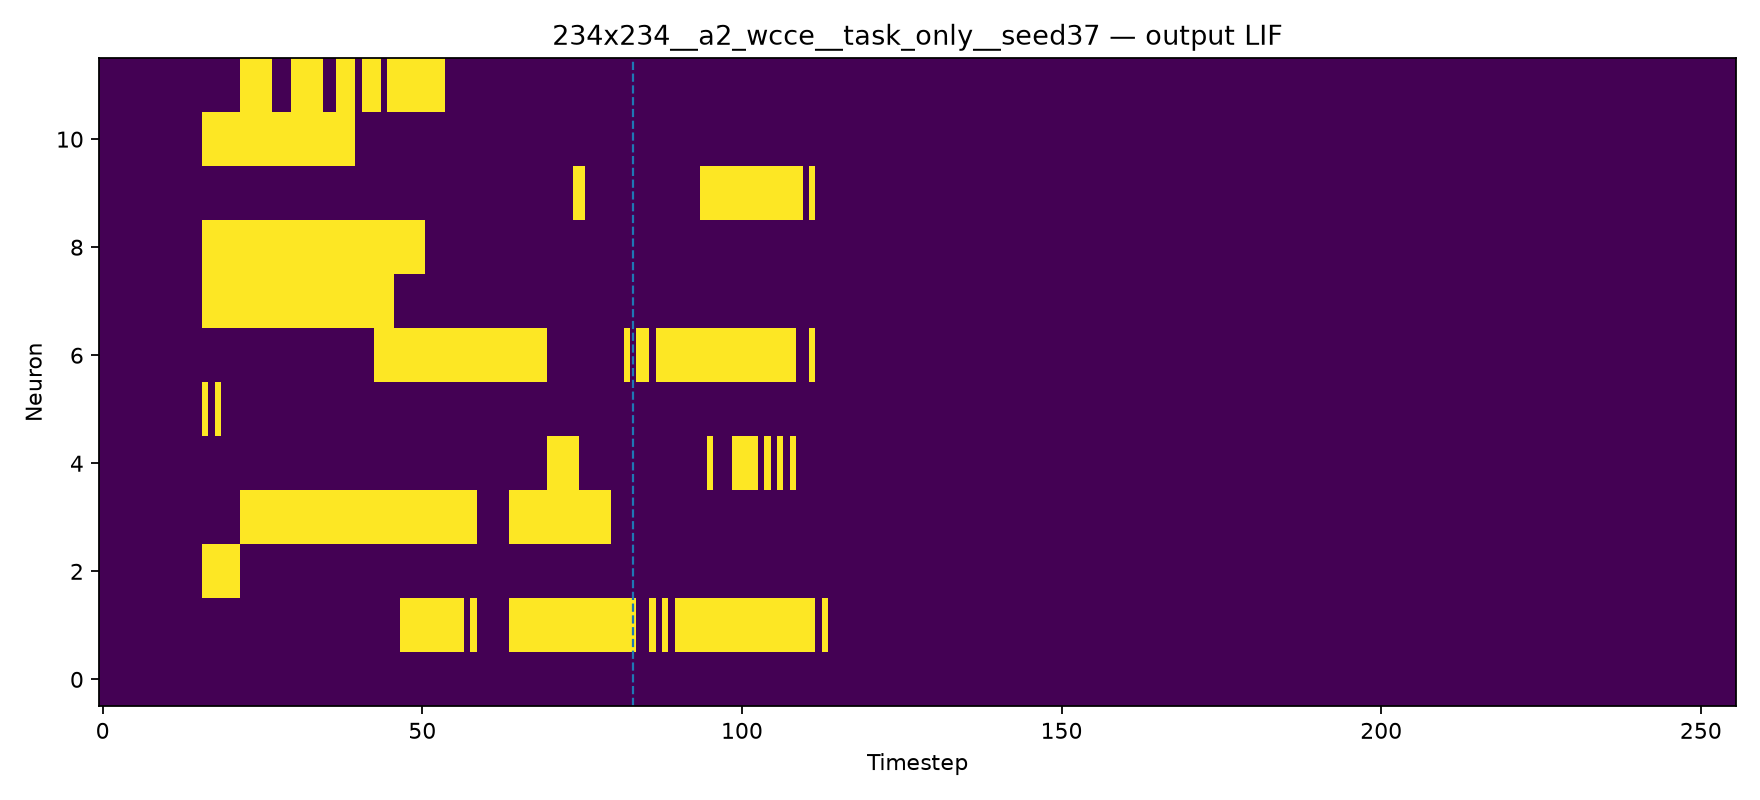

### 234x345 — seed 11

**L1**

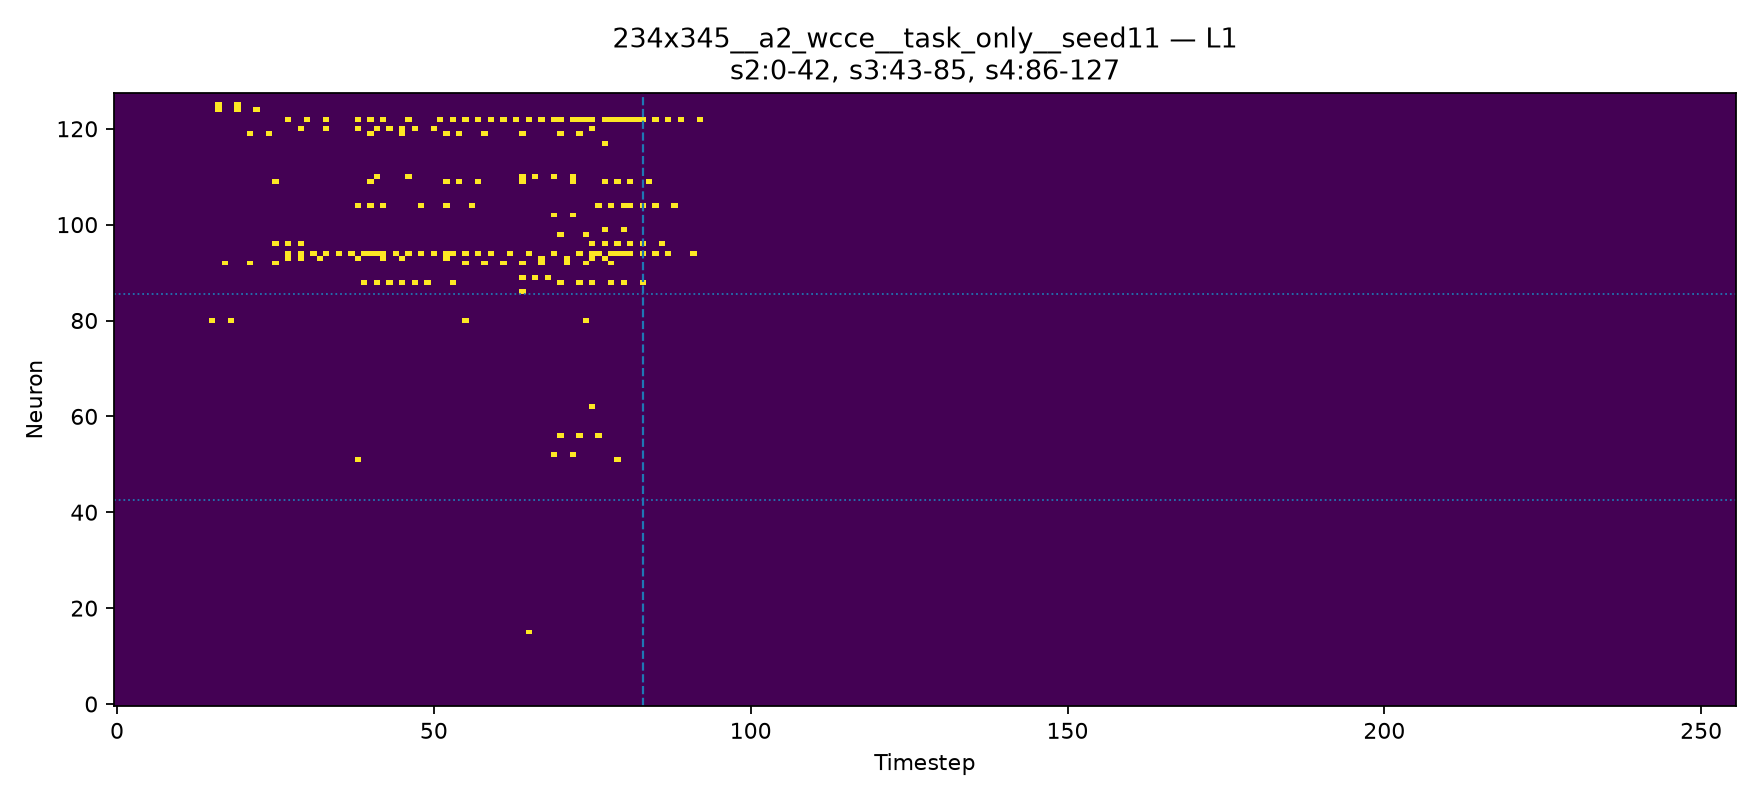

**L2**

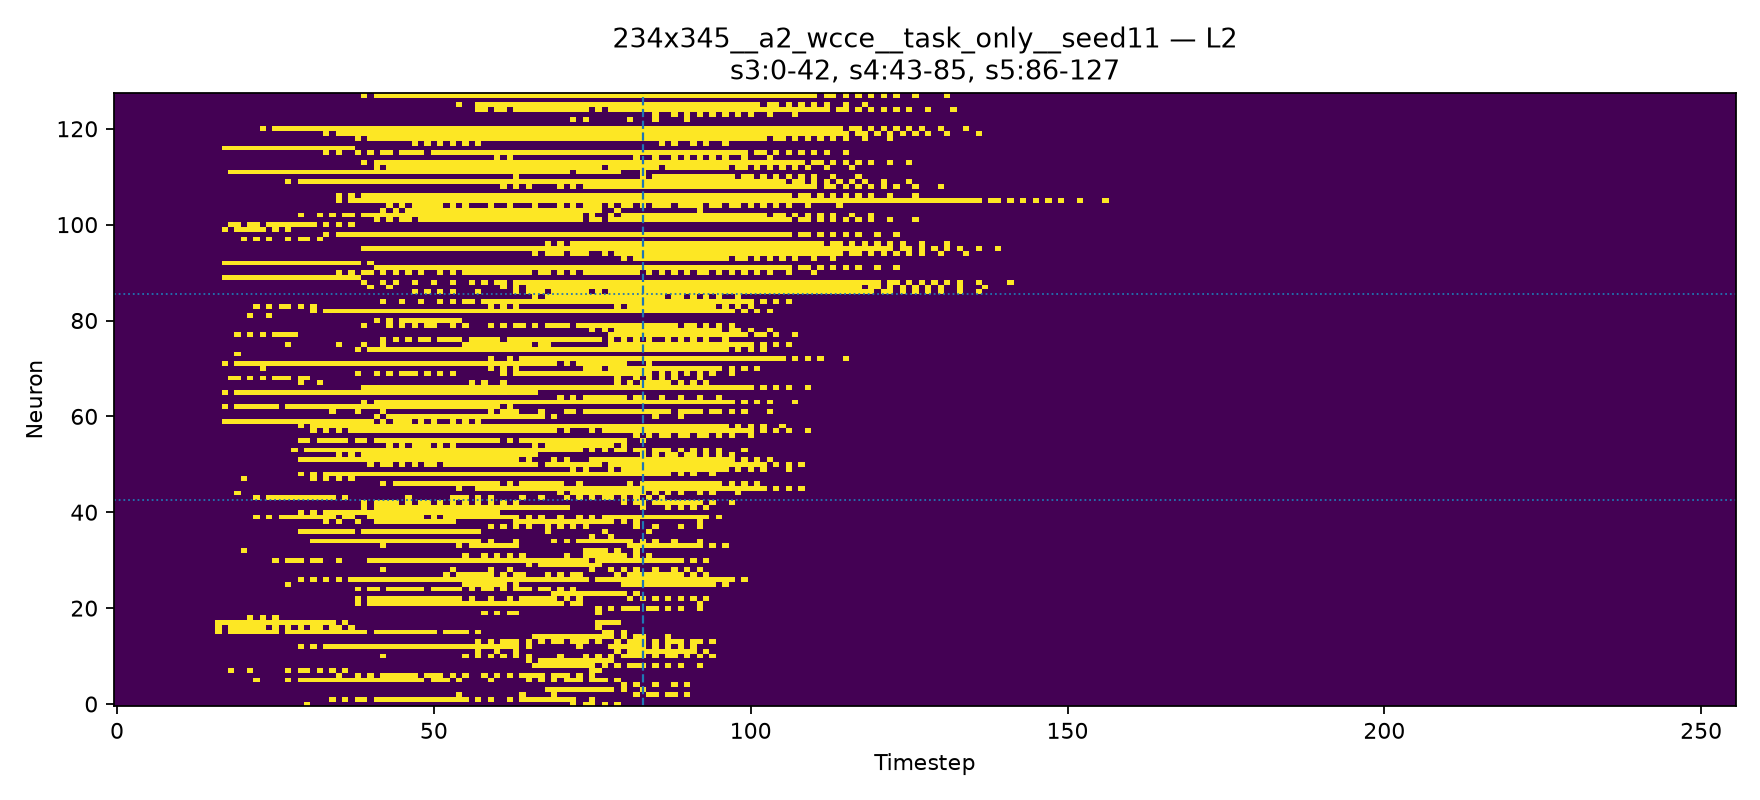

**OUTPUT**

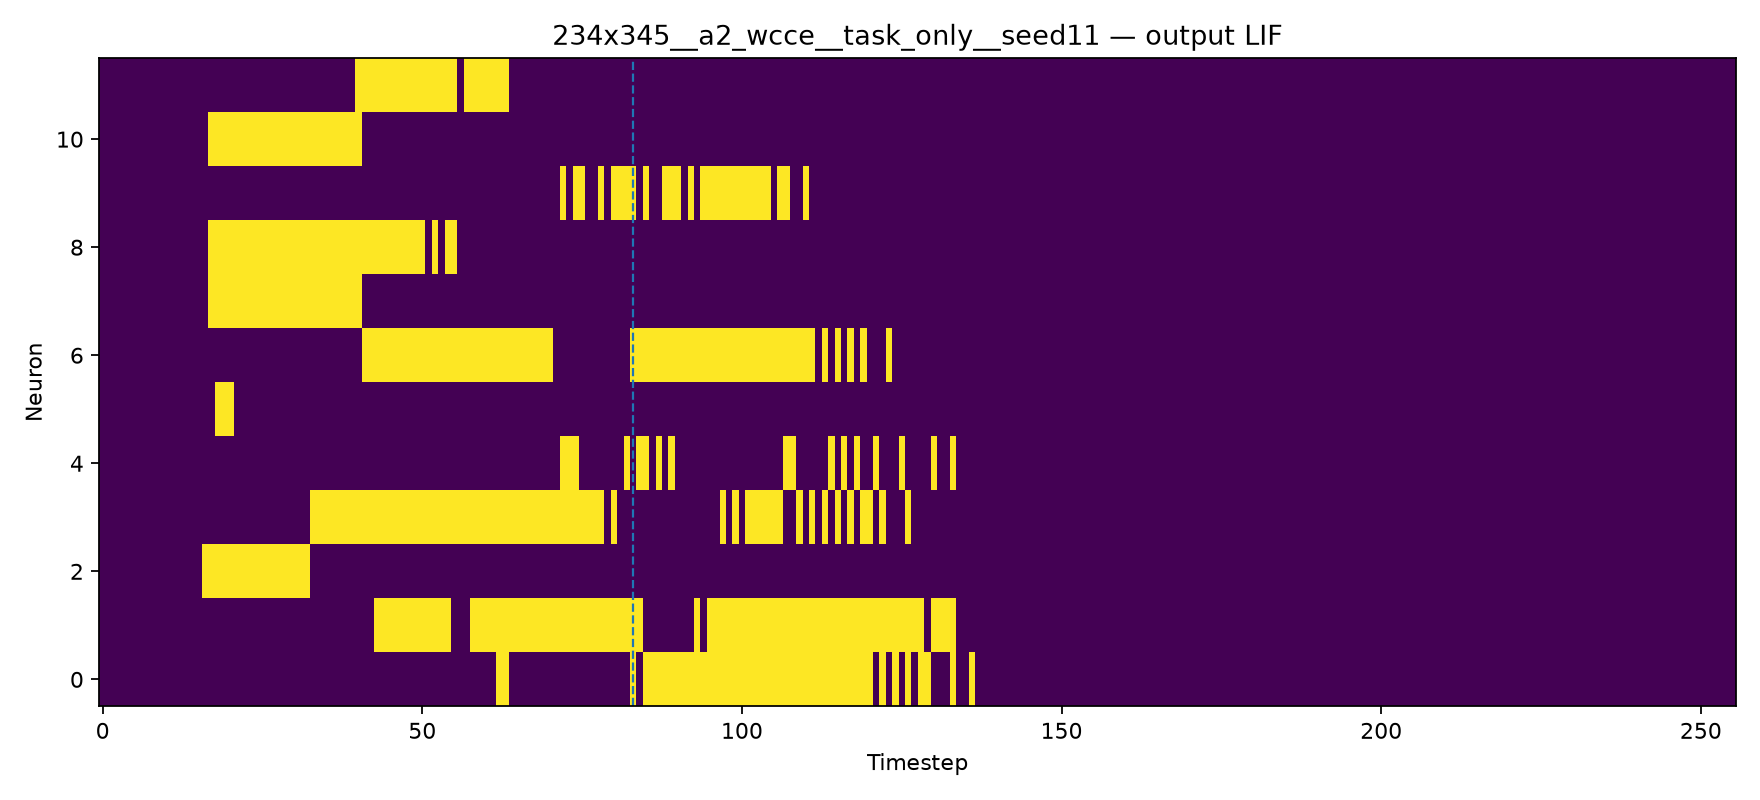

### 234x345 — seed 23

**L1**

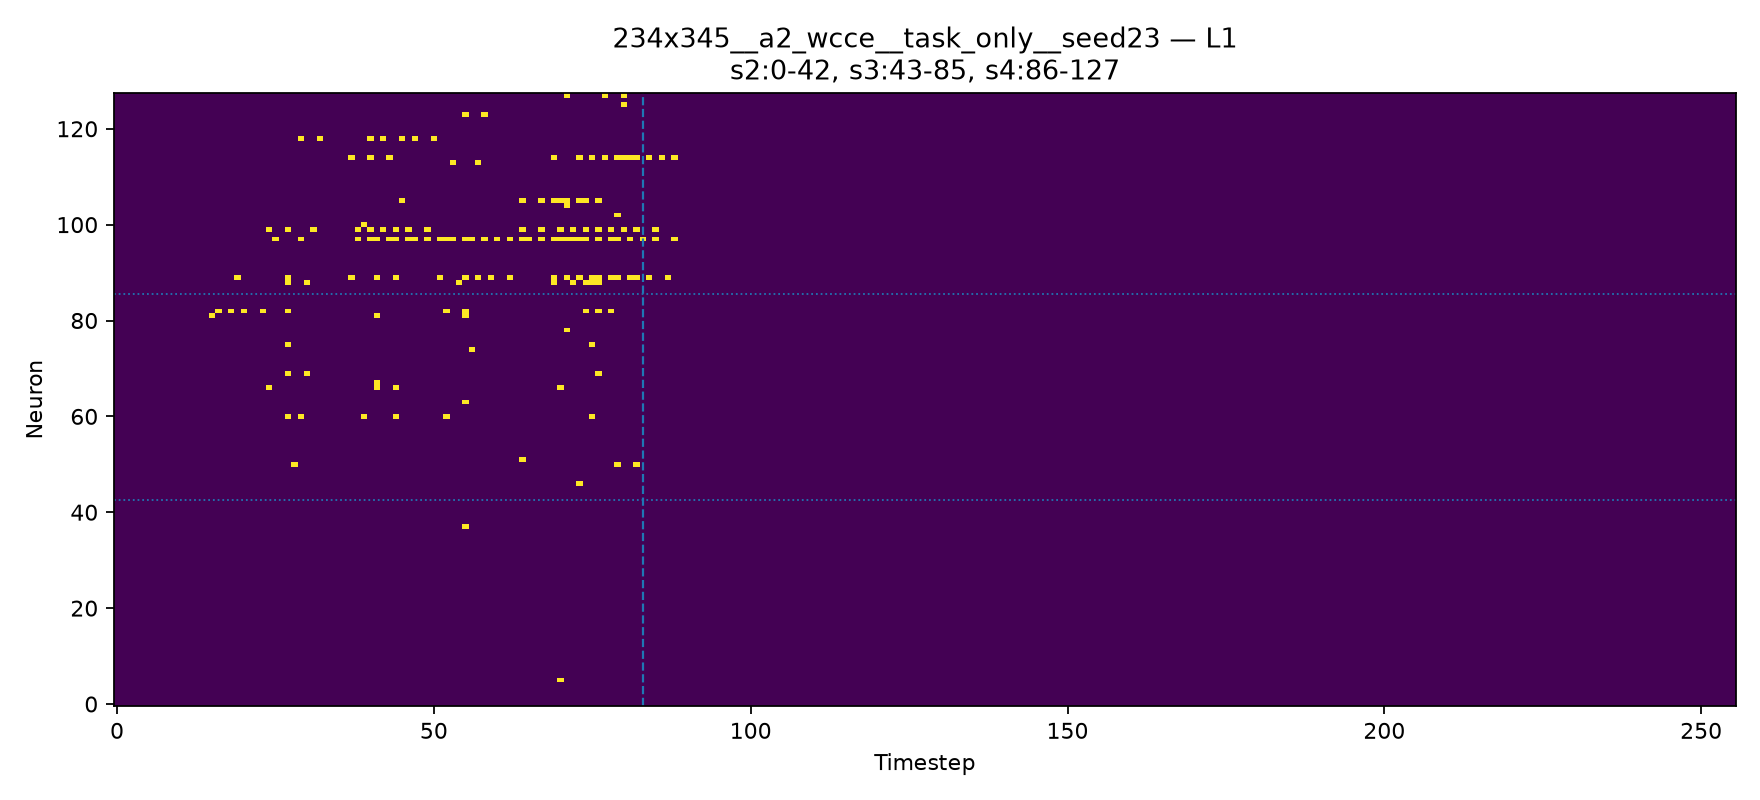

**L2**

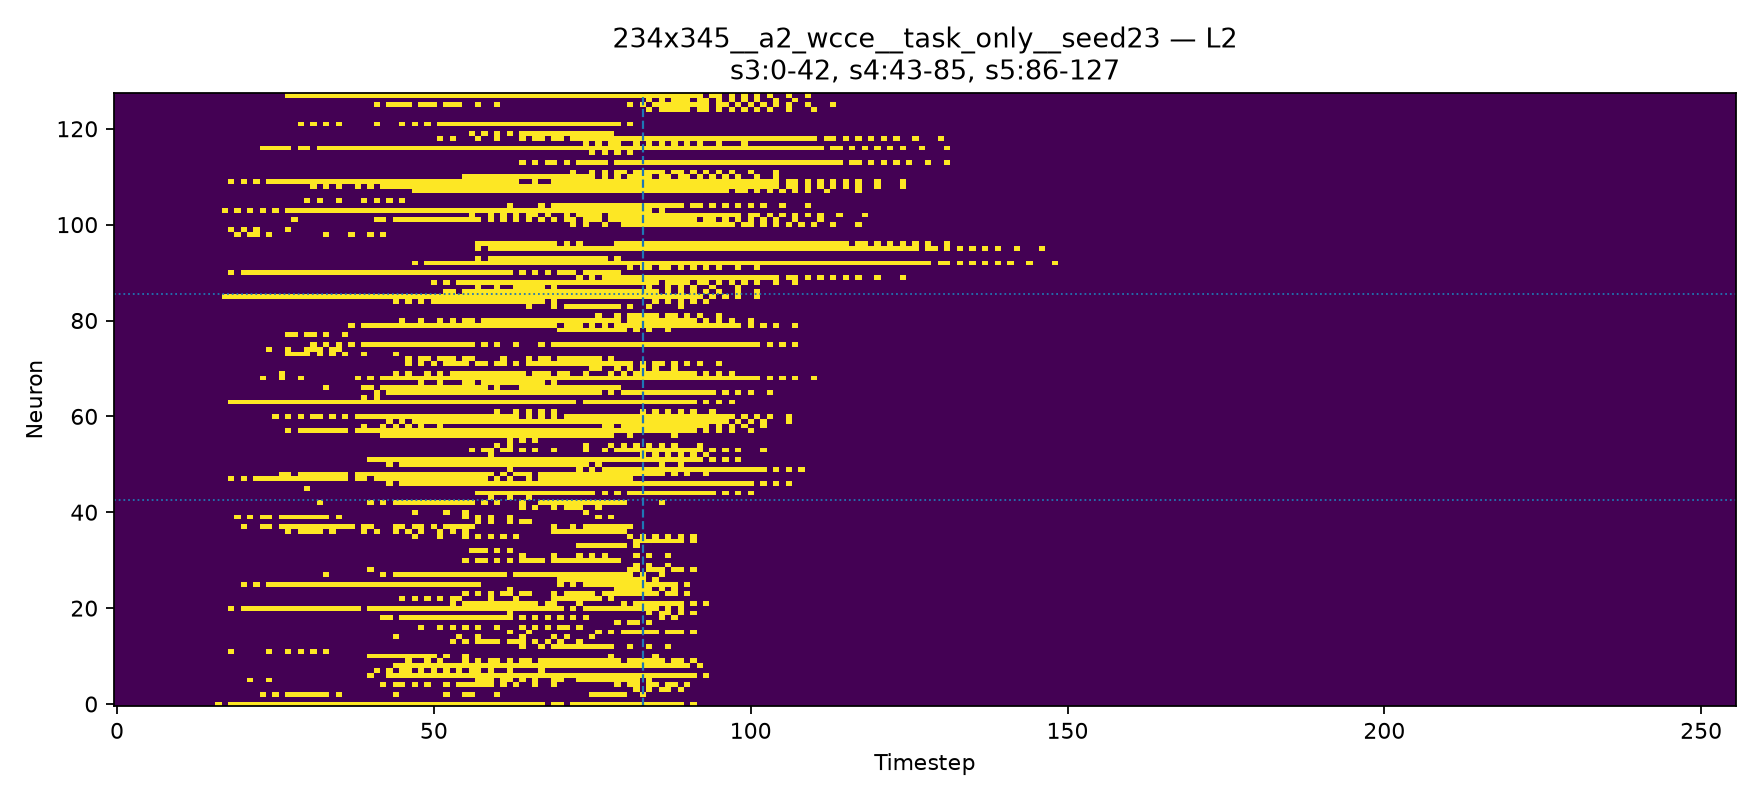

**OUTPUT**

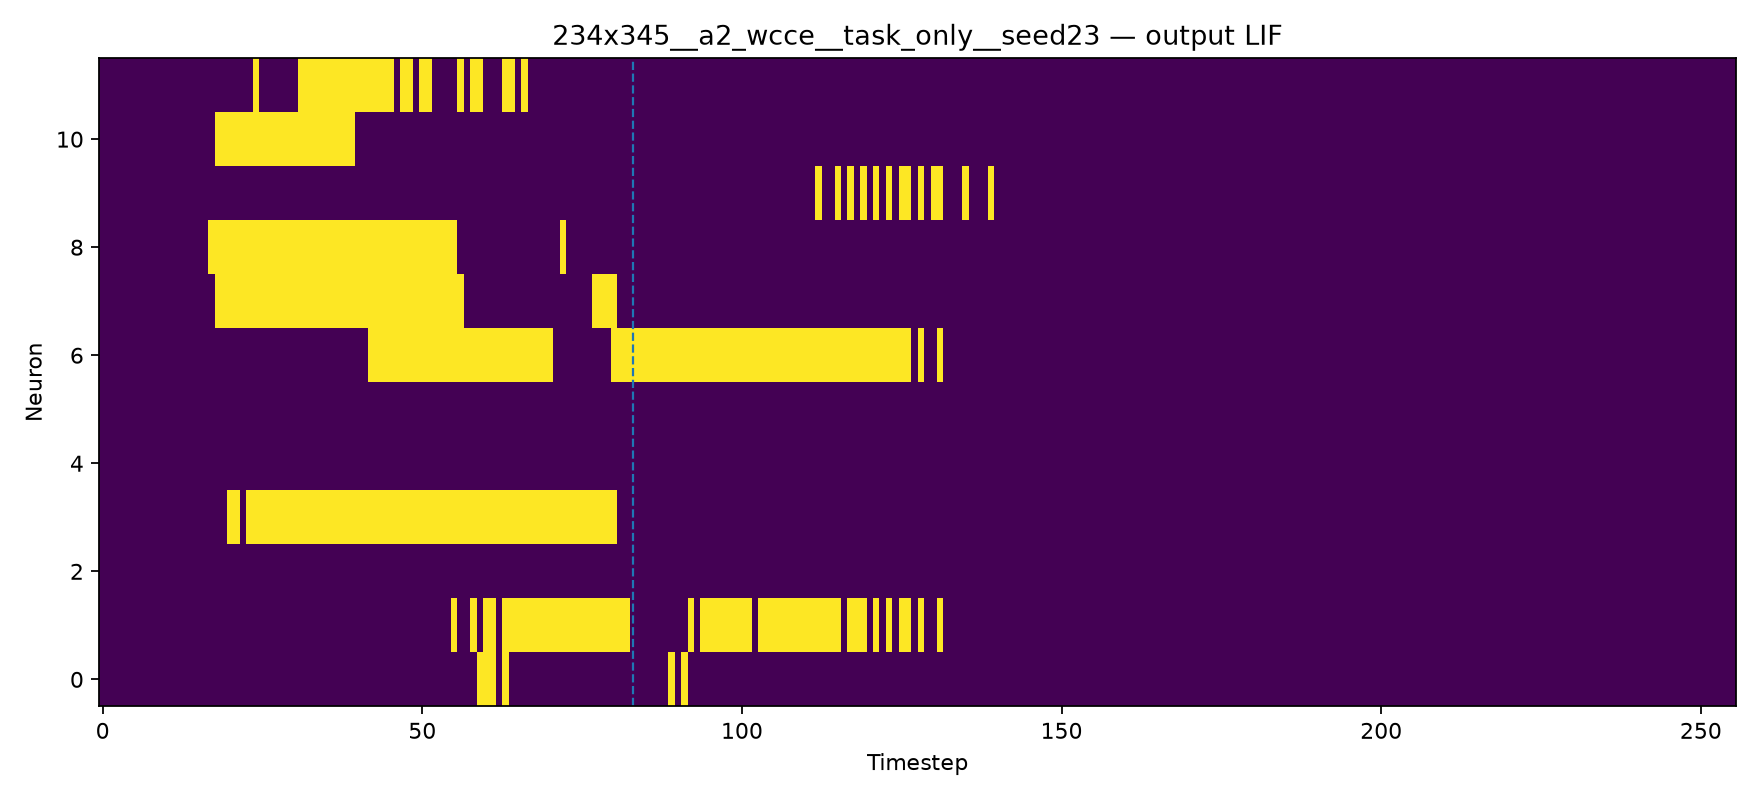

### 234x345 — seed 37

**L1**

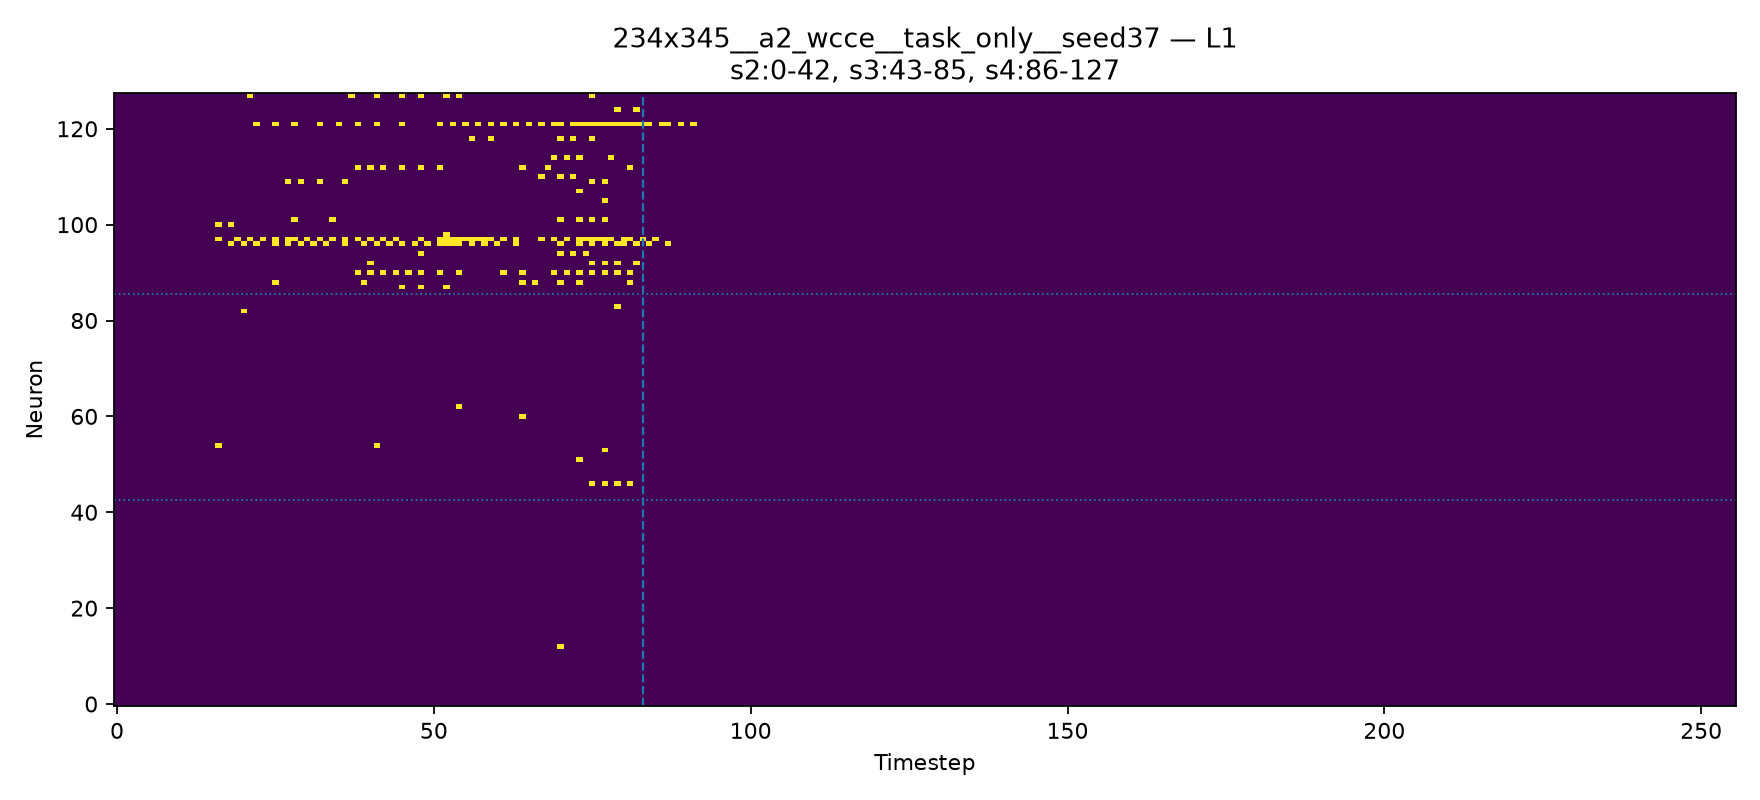

**L2**

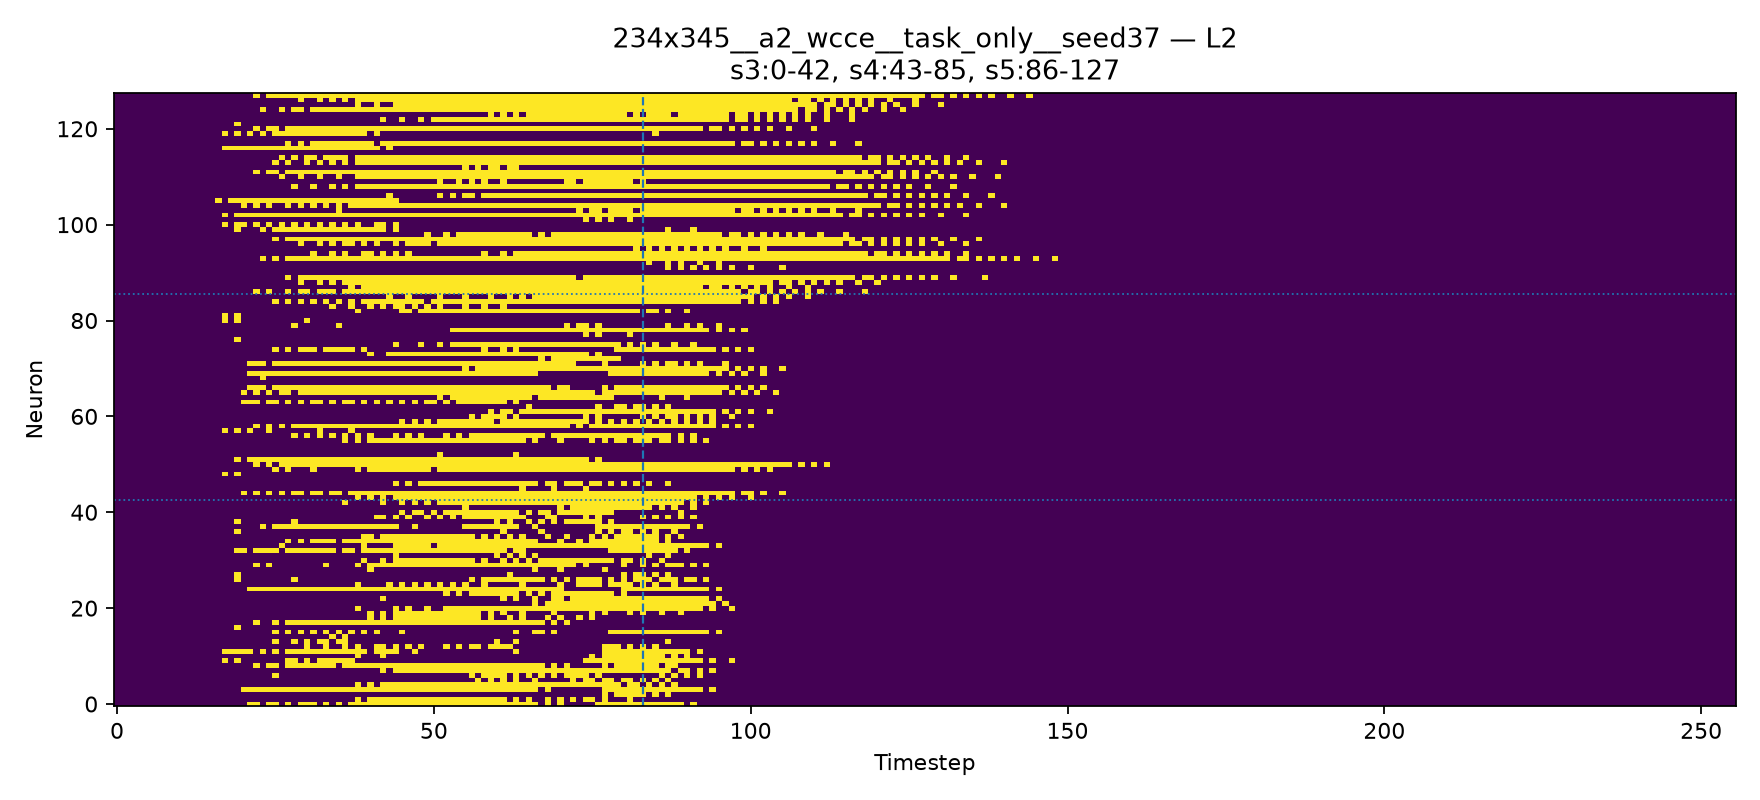

**OUTPUT**

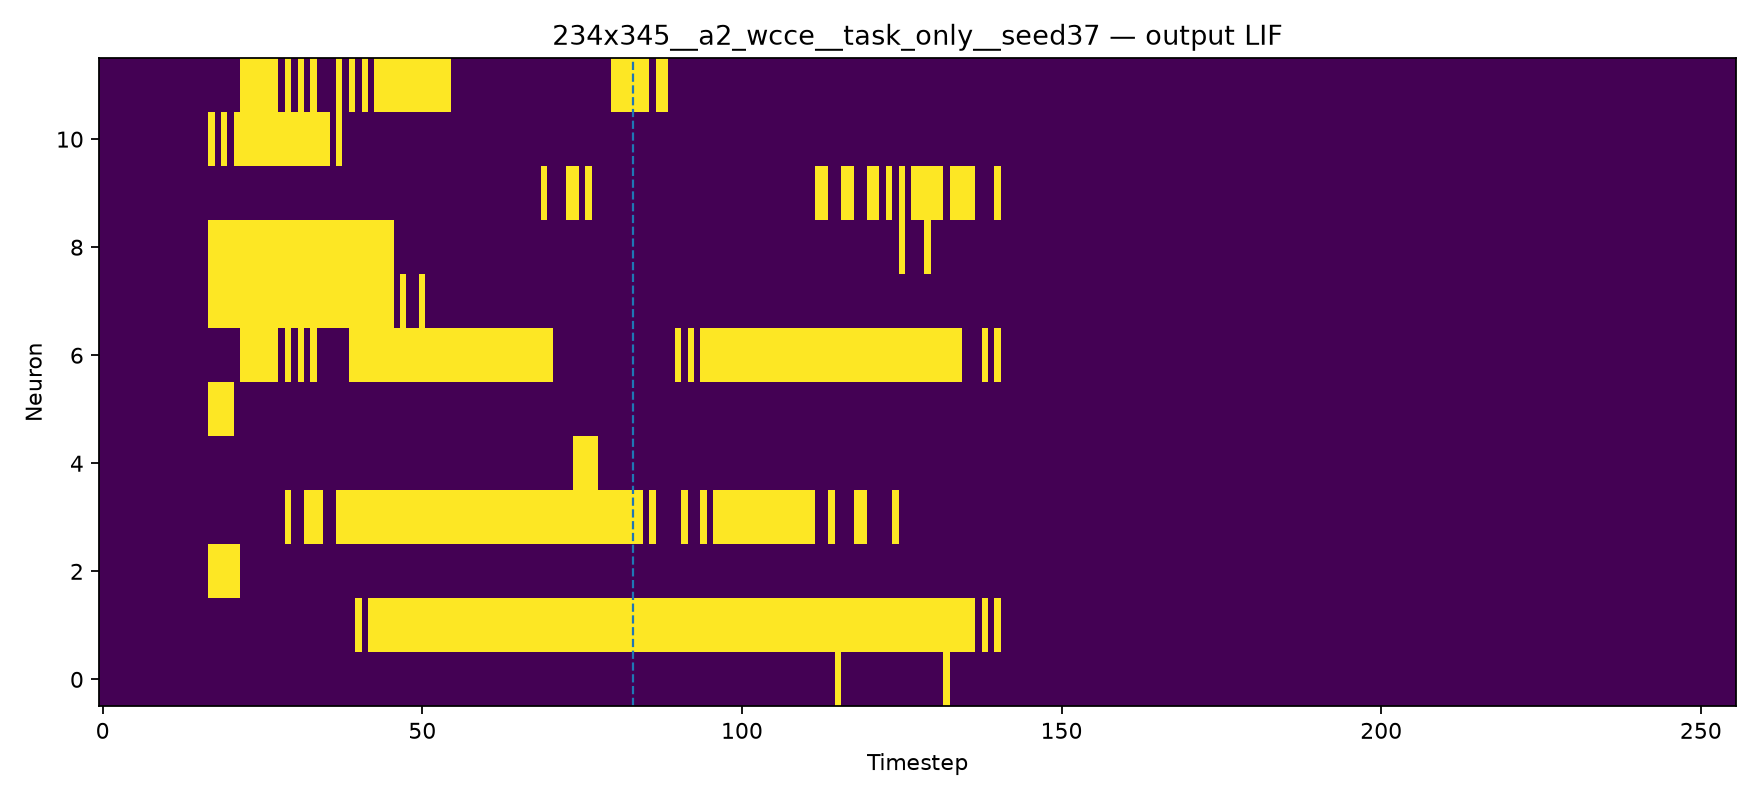

In [8]:
for architecture in manifest['architectures']:
    for seed in manifest['seeds']:
        rows = rasters[(rasters.architecture == architecture) & (rasters.seed == seed)]
        display(Markdown(f'### {architecture} — seed {seed}'))
        for layer in ['l1', 'l2', 'output']:
            row = rows[rows.layer == layer].iloc[0]
            display(Markdown(f'**{layer.upper()}**'))
            display(Image(filename=str(repo / row.raster_png)))